# Objectives

The main objective is to identify opportunities to increase and protect Net Product Sales by answering two broad questions:
1. Which identified customers, products, and time periods contribute most to gross product sales?
2. Where are recorded cancellations most concentrated by customer, product, and time?

## Candidate Monthly KPIs
The following are candidate monthly KPIs that should be tested to confirm how valuable they are and whether or not they should be tracked:
- **Gross product sales**
- **Cancellation value**
- **Net product sales**
- **Gross units ordered**
- **Cancelled units**
- **Net units ordered**
- **Purchase count**
- **Cancellation count**
- **Cancellation rate**
- **Cancellation rate by value**
- **Avg. order value**
- **Repeat-purchase rate**
- **Avg. customer value**

# Code

## Initialization

In [1]:
import os
os.chdir('..')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from src.calculators import percent

In [3]:
clean_df = pd.read_parquet('data/processed/Online_Retail_cleaned.parquet')
# Importing the data from Kaggle directly is also an option

In [4]:
df = clean_df.copy()
# This copy is made just in case we want to reset df without loading the dataset again

### Data Types Check

In [5]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Duplicate                bool
Cancelled                bool
dtype: object

All columns have the correct data type.

## Reusable Data Views

In [6]:
df['LineValue'] = df['Quantity'] * df['UnitPrice']

In [7]:
df['Month'] = df['InvoiceDate'].dt.strftime('%b %Y')

In [8]:
df['Date'] = df['InvoiceDate'].dt.date
df['DayOfMonth'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [9]:
latest_timestamp = df['InvoiceDate'].max()

In [10]:
date_index = pd.date_range(df['InvoiceDate'].min().date(), df['InvoiceDate'].max().date())

In [11]:
purchase_rows = df[~df['Cancelled']].copy()

In [12]:
cancellation_rows = df[df['Cancelled']].copy()

In [13]:
orders = (
    purchase_rows.groupby('InvoiceNo').agg(
        CustomerID=('CustomerID', 'first'),
        TotalValue=('LineValue', 'sum'),
        AvgUnitPrice=('UnitPrice', 'mean'),
        HighestPrice=('UnitPrice', 'max'),
        TotalUnits=('Quantity', 'sum'),
        AvgUnits=('Quantity', 'mean'),
        UniqueProducts=('StockCode', 'nunique'),
        InvoiceDate=('InvoiceDate', 'first'),
        Date=('Date', 'first'),
        Month=('Month', 'first'),
        DayOfMonth=('DayOfMonth', 'first'),
        Weekday=('Weekday', 'first'),
        Country=('Country', 'first')
    )
    .reset_index()
)

In [14]:
cancelled_orders = (
    cancellation_rows.groupby('InvoiceNo').agg(
        CustomerID=('CustomerID', 'first'),
        TotalValue=('LineValue', 'sum'),
        AvgUnitPrice=('UnitPrice', 'mean'),
        HighestPrice=('UnitPrice', 'max'),
        TotalUnits=('Quantity', 'sum'),
        AvgUnits=('Quantity', 'mean'),
        UniqueProducts=('StockCode', 'nunique'),
        InvoiceDate=('InvoiceDate', 'first'),
        Date=('Date', 'first'),
        Month=('Month', 'first'),
        DayOfMonth=('DayOfMonth', 'first'),
        Weekday=('Weekday', 'first'),
        Country=('Country', 'first')
    )
    .reset_index()
)

In [92]:
summary = pd.Series(
    {
        'gross_sales':orders['TotalValue'].sum(),
        'net_sales':orders['TotalValue'].sum() - -cancelled_orders['TotalValue'].sum(),
        'gross_units_ordered':orders['TotalUnits'].sum(),
        'net_units_ordered':orders['TotalUnits'].sum() - -cancelled_orders['TotalUnits'].sum(),
        'purchase_count':len(orders),
        'avg_order_value':orders['TotalValue'].mean(),
        'unique_products_count':df['StockCode'].nunique(),
        'identified_customer_count':df['CustomerID'].nunique(),
        'cancellation_count':len(cancelled_orders),
        'cancelled_value':-cancelled_orders['TotalValue'].sum(),
        'cancelled_units':-cancelled_orders['TotalUnits'].sum(),
        'avg_cancellation_value':cancelled_orders['TotalValue'].mean(),
        'cancellation_count_rate':percent(len(cancelled_orders), len(orders)),
        'cancellation_value_rate':percent(-cancelled_orders['TotalValue'].sum(), orders['TotalValue'].sum()),
        'cancellation_units_rate':percent(-cancelled_orders['TotalUnits'].sum(), orders['TotalUnits'].sum()),
        'cancellation_avg_order_value_rate':percent(-cancelled_orders['TotalValue'].mean(), orders['TotalValue'].mean())
    }
)

In [93]:
summary

gross_sales                          10271034.61
net_sales                             9792310.43
gross_units_ordered                      5576996
net_units_ordered                        5304966
purchase_count                             19773
avg_order_value                       519.447459
unique_products_count                       3789
identified_customer_count                   4362
cancellation_count                          3422
cancelled_value                        478724.18
cancelled_units                           272030
avg_cancellation_value                -139.89602
cancellation_count_rate                   17.31%
cancellation_value_rate                    4.66%
cancellation_units_rate                    4.88%
cancellation_avg_order_value_rate         26.93%
dtype: object

## Country Analysis

In [17]:
df['Country'].value_counts()

Country
United Kingdom          491334
Germany                   9095
France                    8234
EIRE                      8071
Spain                     2467
Netherlands               2326
Belgium                   1971
Switzerland               1968
Portugal                  1475
Australia                 1254
Norway                    1059
Italy                      783
Channel Islands            753
Finland                    653
Cyprus                     619
Unspecified                446
Sweden                     437
Austria                    387
Denmark                    375
Japan                      355
Poland                     336
Israel                     297
USA                        291
Hong Kong                  280
Singapore                  215
Iceland                    182
Canada                     150
Greece                     142
Malta                      123
United Arab Emirates        67
European Community          58
RSA                         57


In [18]:
orders_country_proportions = orders['Country'].value_counts() / len(orders)

In [19]:
orders_country_proportions

Country
United Kingdom          0.905325
Germany                 0.022404
France                  0.019319
EIRE                    0.014262
Belgium                 0.004956
Netherlands             0.004703
Spain                   0.004451
Australia               0.002832
Switzerland             0.002529
Portugal                0.002529
Finland                 0.002023
Italy                   0.001770
Sweden                  0.001720
Norway                  0.001618
Channel Islands         0.001264
Poland                  0.000961
Japan                   0.000961
Denmark                 0.000910
Austria                 0.000860
Cyprus                  0.000708
Unspecified             0.000657
Israel                  0.000405
Iceland                 0.000354
Hong Kong               0.000354
Greece                  0.000253
Canada                  0.000253
USA                     0.000253
Malta                   0.000253
Lithuania               0.000202
Singapore               0.000202
Ba

## General Gross Sales Analysis

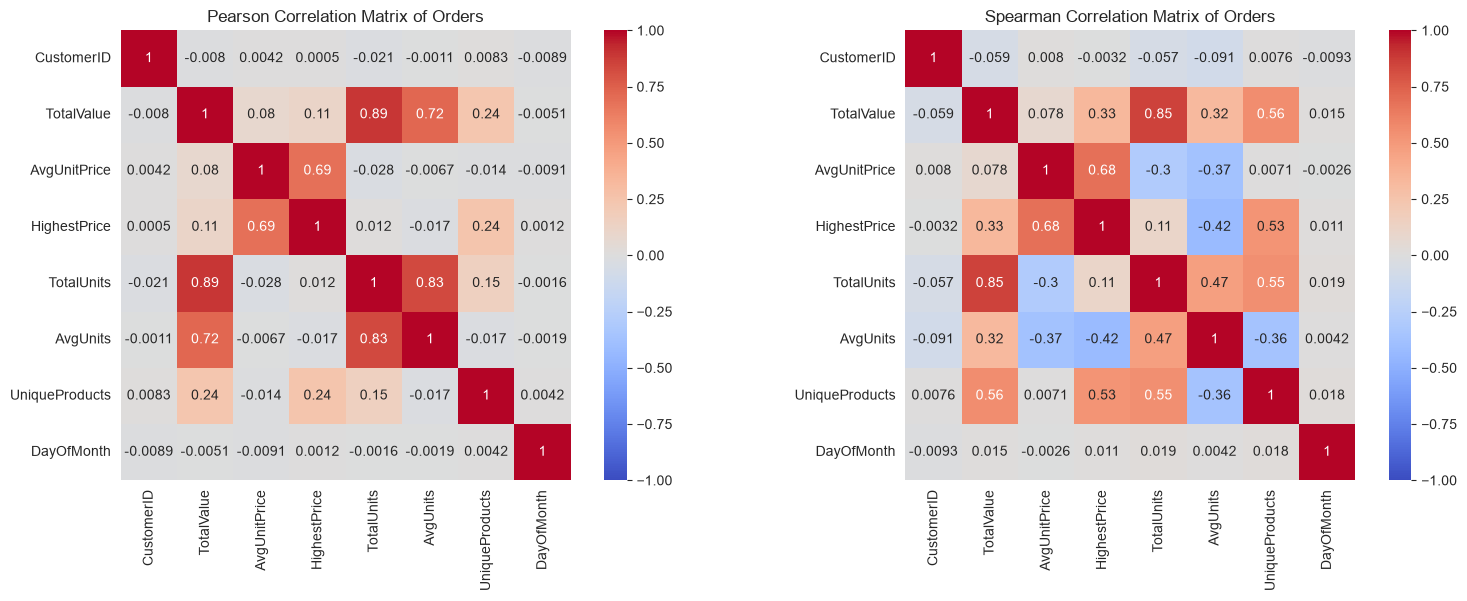

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sns.heatmap(
    data=orders.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax1
)
ax1.set_title('Pearson Correlation Matrix of Orders')

ax2 = axes[1]
sns.heatmap(
    data=orders.corr(method='spearman', numeric_only=True),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax2
)
ax2.set_title('Spearman Correlation Matrix of Orders')

plt.tight_layout()

The substantial difference between the Pearson and Spearman correlations for total units ordered and the number of unique products ordered is likely influenced by extreme order quantities, which may reflect the retailer’s significant wholesale activity.

In [21]:
log_transformed_orders = np.log1p(orders.select_dtypes(include='number'))

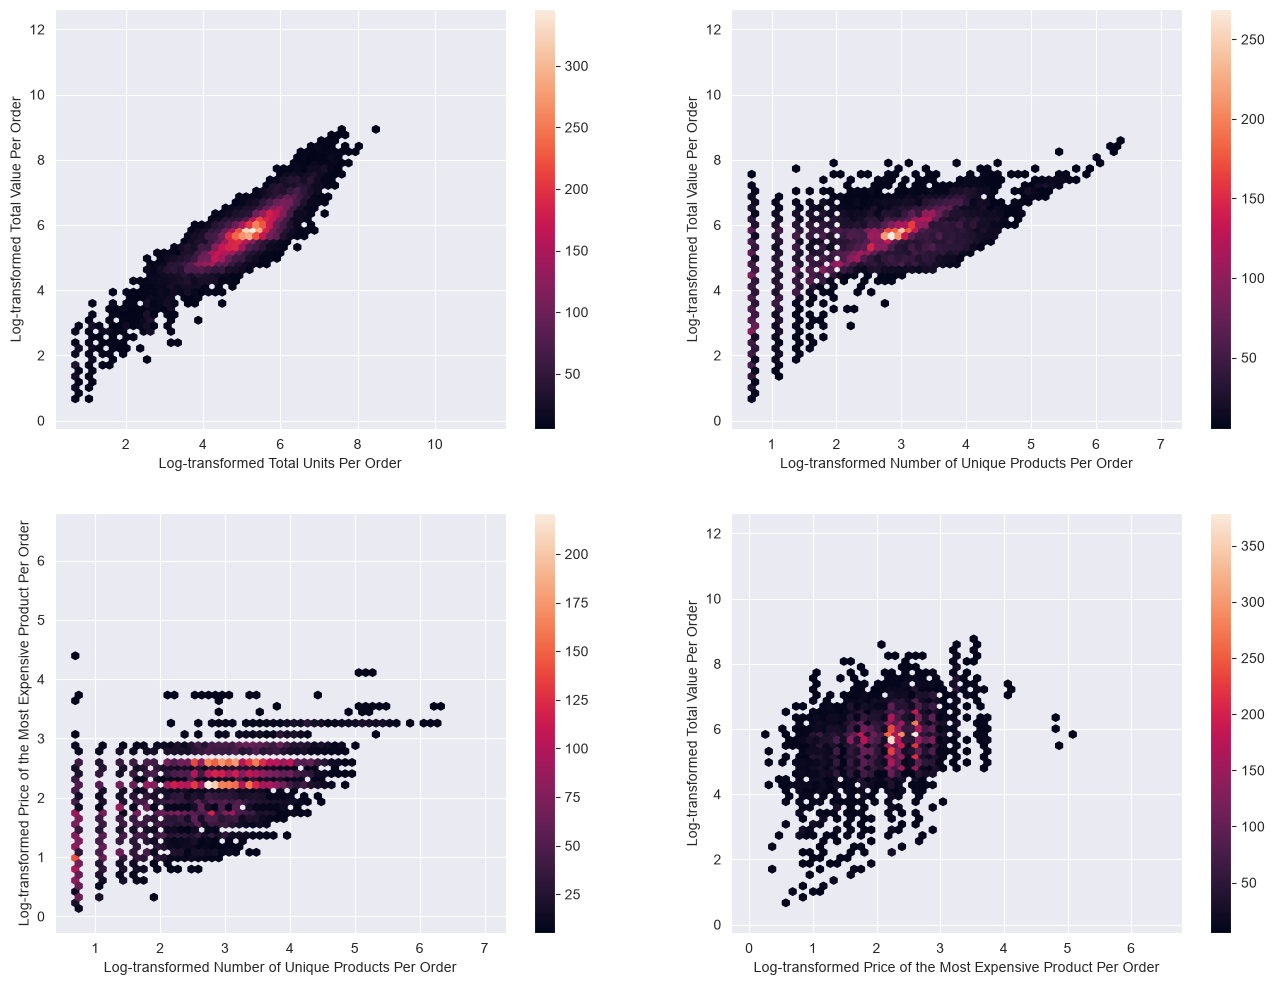

In [22]:
fig, axes =plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0][0]
hexbin1 = ax1.hexbin(
    x=log_transformed_orders['TotalUnits'],
    y=log_transformed_orders['TotalValue'],
    gridsize=60,
    mincnt=5
)
ax1.set_xlabel('Log-transformed Total Units Per Order')
ax1.set_ylabel('Log-transformed Total Value Per Order')

ax2 = axes[0][1]
hexbin2 = ax2.hexbin(
    x=log_transformed_orders['UniqueProducts'],
    y=log_transformed_orders['TotalValue'],
    gridsize=60,
    mincnt=5
)
ax2.set_xlabel('Log-transformed Number of Unique Products Per Order')
ax2.set_ylabel('Log-transformed Total Value Per Order')

ax3 = axes[1][0]
hexbin3 = ax3.hexbin(
    x=log_transformed_orders['UniqueProducts'],
    y=log_transformed_orders['HighestPrice'],
    gridsize=60,
    mincnt=5
)
ax3.set_xlabel('Log-transformed Number of Unique Products Per Order')
ax3.set_ylabel('Log-transformed Price of the Most Expensive Product Per Order')

ax4 = axes[1][1]
hexbin4 = ax4.hexbin(
    x=log_transformed_orders['HighestPrice'],
    y=log_transformed_orders['TotalValue'],
    gridsize=60,
    mincnt=5
)
ax4.set_xlabel('Log-transformed Price of the Most Expensive Product Per Order')
ax4.set_ylabel('Log-transformed Total Value Per Order')

plt.colorbar(hexbin1)
plt.colorbar(hexbin2)
plt.colorbar(hexbin3)
plt.colorbar(hexbin4)

There is a very strong linear relationship between order value and total units per order.

There seems to be a relationship between order value and the amount of unique items ordered.

### Gross Sales Performance Over Time

Let's check how many days does the data cover in December 2010 and December 2011

In [23]:
print(purchase_rows['Date'].nunique())
print(purchase_rows['Date'].min())
print(purchase_rows['Date'].max())

305
2010-12-01
2011-12-09


In [24]:
unique_days_each_month = purchase_rows.groupby('Month')['DayOfMonth'].nunique()
unique_days_each_month = unique_days_each_month.reindex(purchase_rows['Month'].unique())
unique_days_each_month

Month
Dec 2010    20
Jan 2011    24
Feb 2011    24
Mar 2011    27
Apr 2011    21
May 2011    25
Jun 2011    26
Jul 2011    26
Aug 2011    26
Sep 2011    26
Oct 2011    26
Nov 2011    26
Dec 2011     8
Name: DayOfMonth, dtype: int64

Despite the data spanning over 13 months (persumably 396 days in total), it only has 305 days where sales happened.

There seems to be whole days that don't have any purchases.

Sales in December 2011 only happened in 8 unique days. The last day recorded was 9th of December 2011.

<BarContainer object of 7 artists>

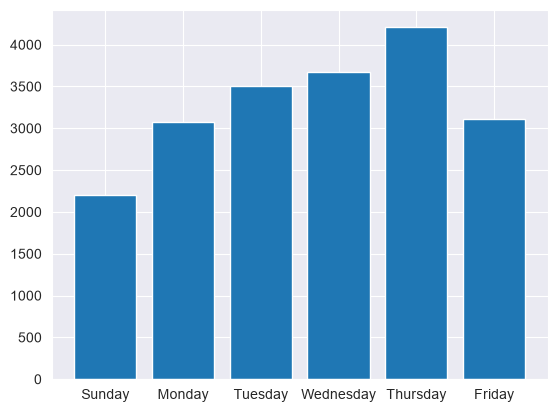

In [25]:
weekday_purchase_count = orders.groupby('Weekday')['Weekday'].count()
weekday_purchase_count = weekday_purchase_count.reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
plt.bar(weekday_purchase_count.index, weekday_purchase_count)

There seems to be no rows with Saturday as Weekday. However, this doesn't necessarily mean that there are no purchases on Saturday because the date records are taken when the invoice is recorded, not when the purchase actually happens.

Since there are no available stakeholders, the reasoning behind missing Saturday records is unknown.

In [26]:
daily_gross_sales = purchase_rows.groupby('Date')['LineValue'].sum().reindex(date_index, fill_value=0)
daily_purchase_count = orders.groupby('Date')['InvoiceNo'].count().reindex(date_index, fill_value=0)
daily_gross_units_bought = purchase_rows.groupby('Date')['Quantity'].sum().reindex(date_index, fill_value=0)
daily_avg_order_value = (daily_gross_sales / daily_purchase_count).reindex(date_index, fill_value=0)

daily_summary = pd.DataFrame(
    {
        'GrossSales':daily_gross_sales,
        'PurchaseCount':daily_purchase_count,
        'GrossUnits':daily_gross_units_bought,
        'AvgOrderValue':daily_avg_order_value
    }
)

rolling_7day_gross_sales = daily_gross_sales.rolling(window=7, min_periods=1).mean()
rolling_7day_purchase_count = daily_purchase_count.rolling(window=7, min_periods=1).mean()
rolling_7day_gross_units_bought = daily_gross_units_bought.rolling(window=7, min_periods=1).mean()
rolling_7day_avg_order_value = daily_avg_order_value.rolling(window=7, min_periods=1).mean()

monthly_gross_sales = purchase_rows.groupby('Month')['LineValue'].sum().reindex(purchase_rows['Month'].unique())
monthly_purchase_count = orders.groupby('Month')['InvoiceNo'].count().reindex(orders['Month'].unique())
monthly_gross_units_bought = purchase_rows.groupby('Month')['Quantity'].sum().reindex(purchase_rows['Month'].unique())

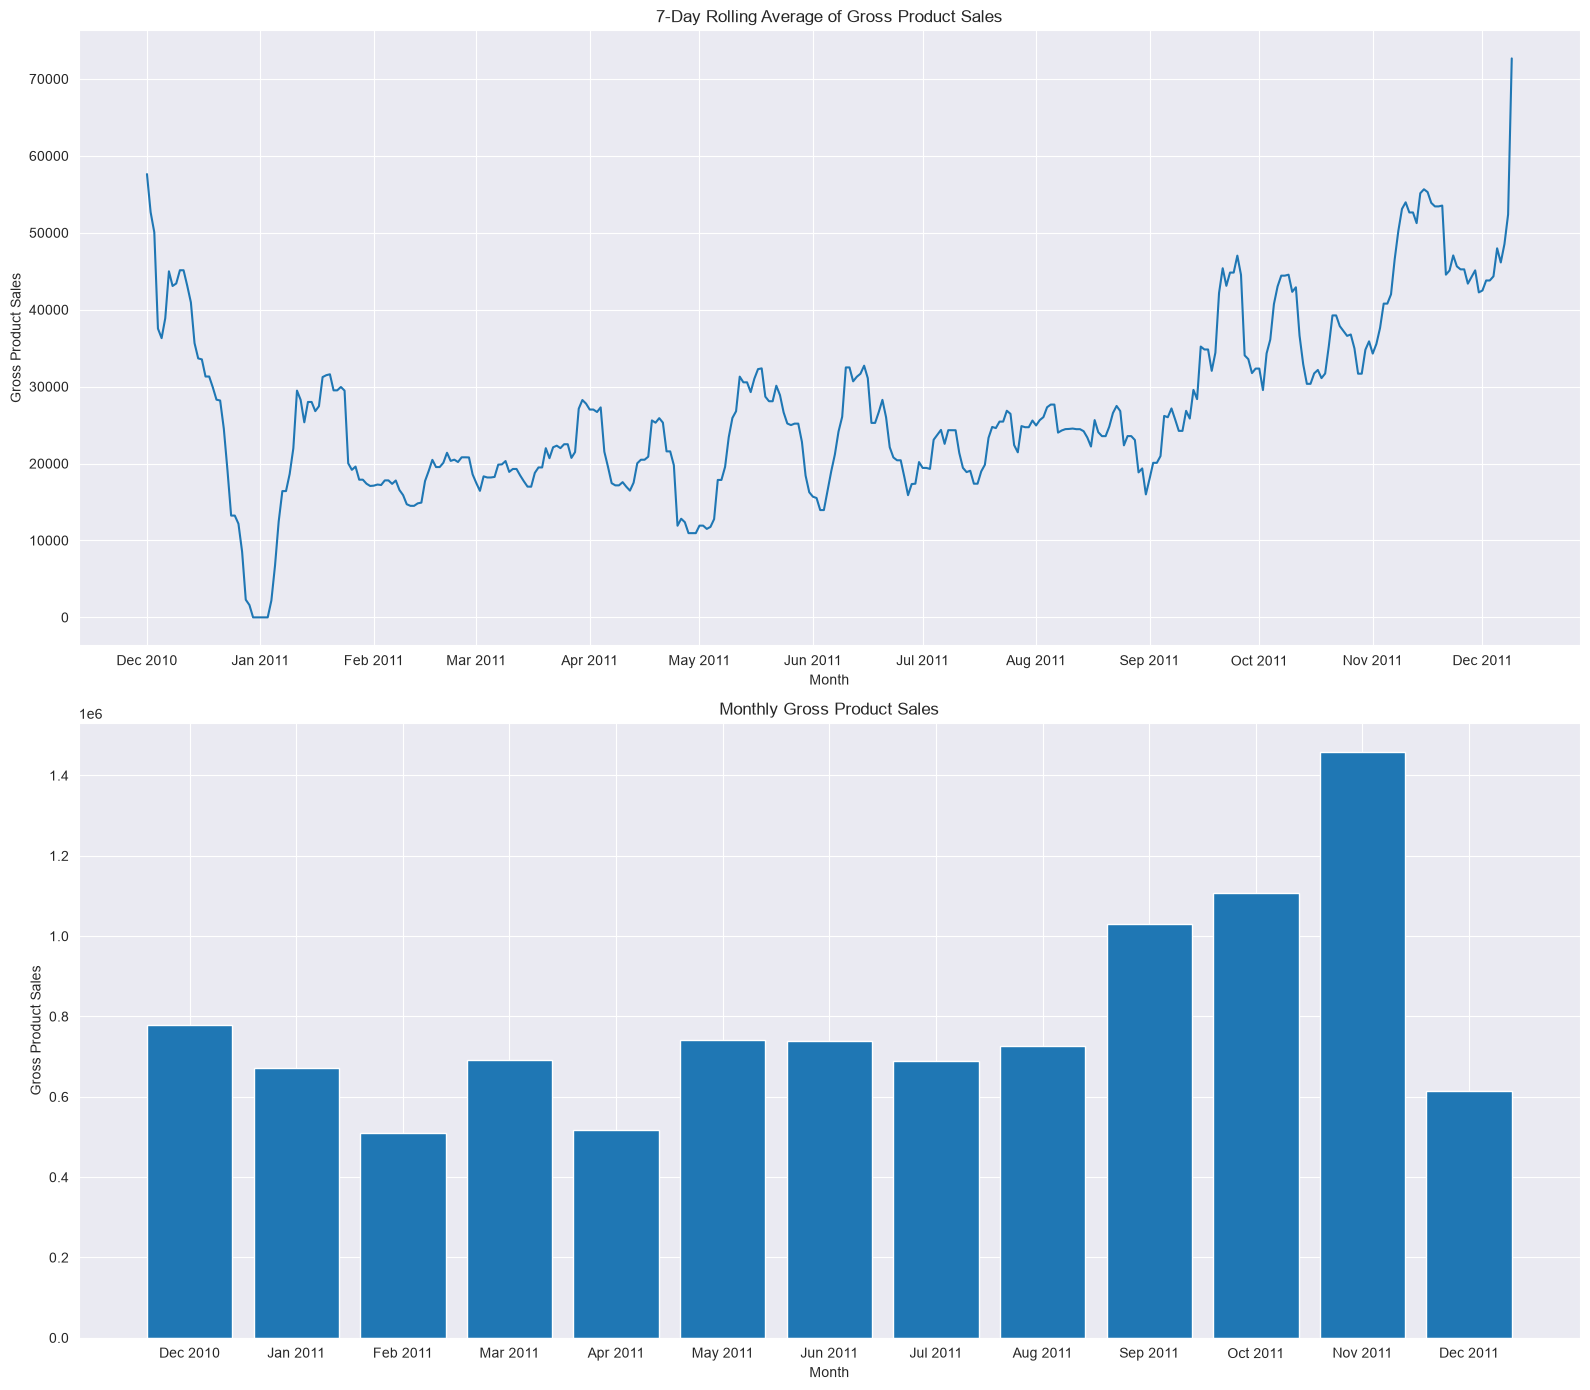

In [100]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

ax1 = axes[0]
date_ticks = pd.date_range(start="2010-12-01", end="2011-12-01", freq="MS")
ax1.set_xticks(date_ticks)
ax1.set_xticklabels([date.strftime("%b %Y") for date in date_ticks])
ax1.plot(rolling_7day_gross_sales)
ax1.set_title("7-Day Rolling Average of Gross Product Sales")
ax1.set_xlabel("Month")
ax1.set_ylabel("Gross Product Sales")

ax2 = axes[1]
ax2.bar(monthly_gross_sales.index, monthly_gross_sales)
ax2.set_title("Monthly Gross Product Sales")
ax2.set_xlabel("Month")
ax2.set_ylabel("Gross Product Sales")

plt.tight_layout()

There is a significant drop of sales at the end of December 2010, reaching zero sales.

Sales seem to have increased in the last four months, peaking at the beginning of December 2011.

Even though December 2011 only spans over 8 days compared to 20 days in December 2010, Sales in December 2011 are not that much less than in December 2010 as shown in the bar plot. This carries the potential meaning of the company's improvement after 1 year, though more data is needed to confirm this claim.

There isn't much difference between monthly sales and monthly number of sales.

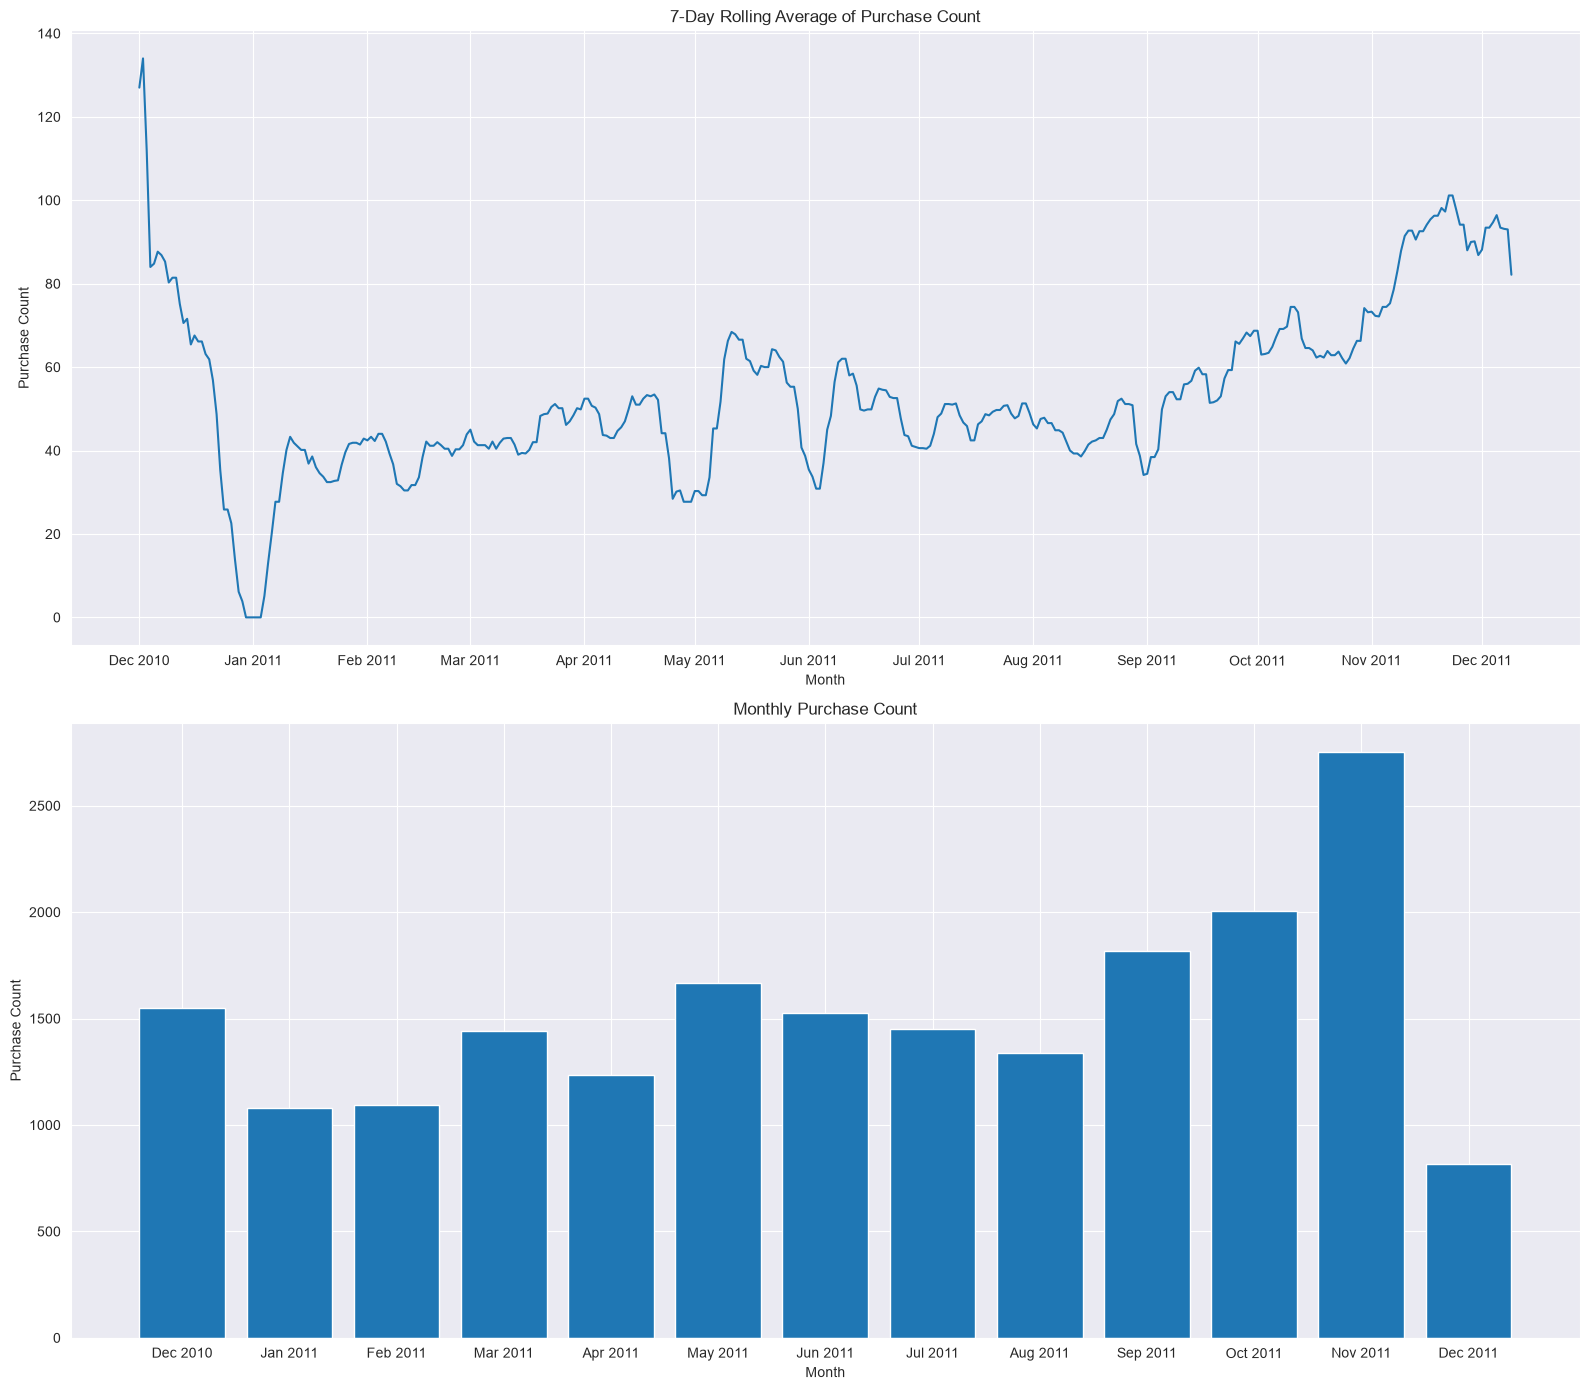

In [107]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

ax1 = axes[0]
date_ticks = pd.date_range(start="2010-12-01", end="2011-12-01", freq="MS")
ax1.set_xticks(date_ticks)
ax1.set_xticklabels([date.strftime("%b %Y") for date in date_ticks])
ax1.plot(rolling_7day_purchase_count)
ax1.set_title("7-Day Rolling Average of Purchase Count")
ax1.set_xlabel("Month")
ax1.set_ylabel("Purchase Count")

ax2 = axes[1]
ax2.bar(monthly_purchase_count.index, monthly_purchase_count)
ax2.set_title("Monthly Purchase Count")
ax2.set_xlabel("Month")
ax2.set_ylabel("Purchase Count")

plt.tight_layout()

The drop at the end of 2010 seems to be caused mainly by a significant lack of purchase activity. Though zero purchases for one or a few days is unlikely to have been caused by customer behavior and is more likely to be things such as maintenance or system problems.

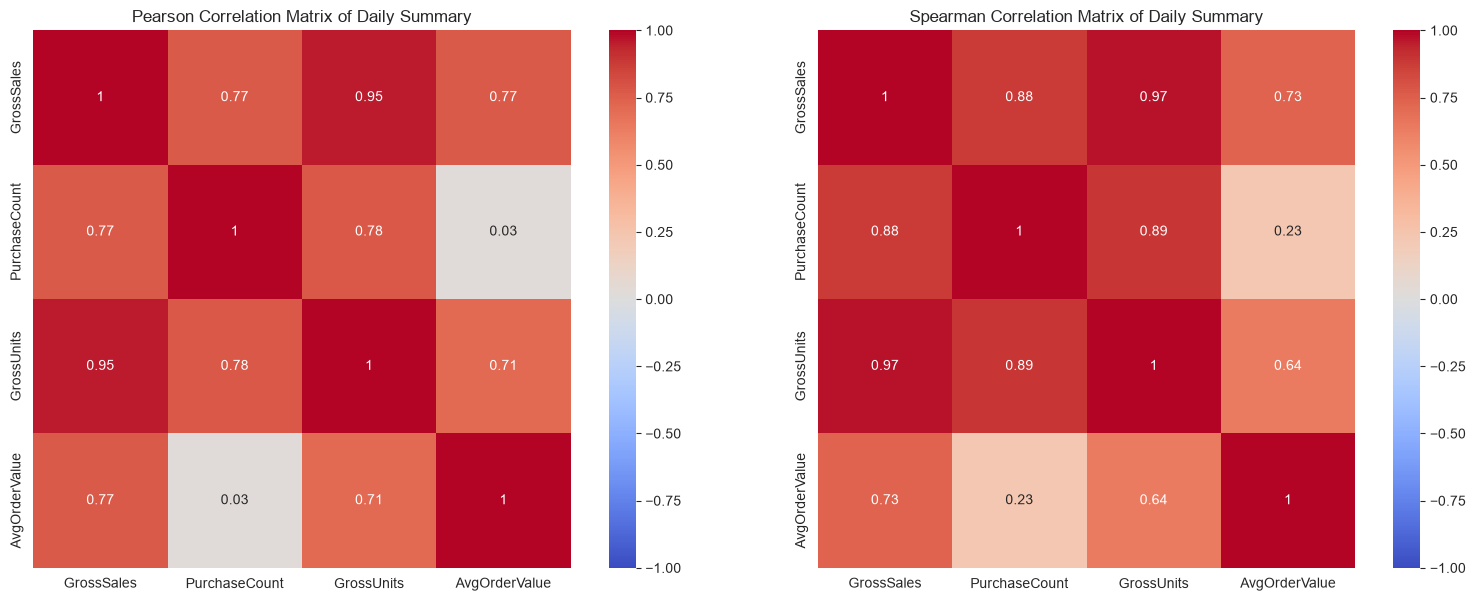

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sns.heatmap(
    daily_summary.corr(),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax1
)
ax1.set_title('Pearson Correlation Matrix of Daily Summary')

ax2 = axes[1]
sns.heatmap(
    daily_summary.corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax2
)
ax2.set_title('Spearman Correlation Matrix of Daily Summary')

plt.tight_layout()

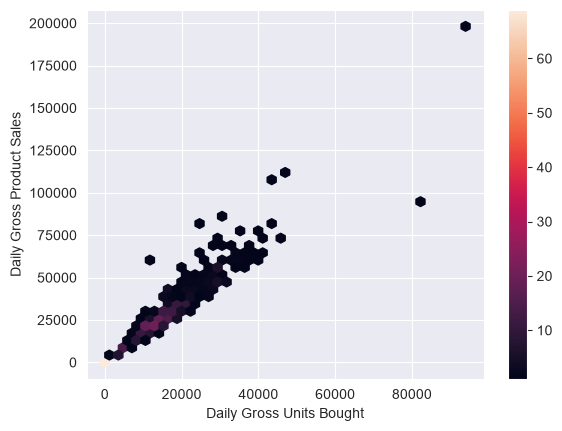

In [30]:
plt.hexbin(
    x=daily_gross_units_bought,
    y=daily_gross_sales,
    gridsize=40,
    mincnt=1
)
plt.xlabel('Daily Gross Units Bought')
plt.ylabel('Daily Gross Product Sales')
plt.colorbar()

There is a strong correlation between Daily Gross Product Sales and Daily Gross Units Bought, indicating that fluctuations in sales is mainly driven by changes in order volume.

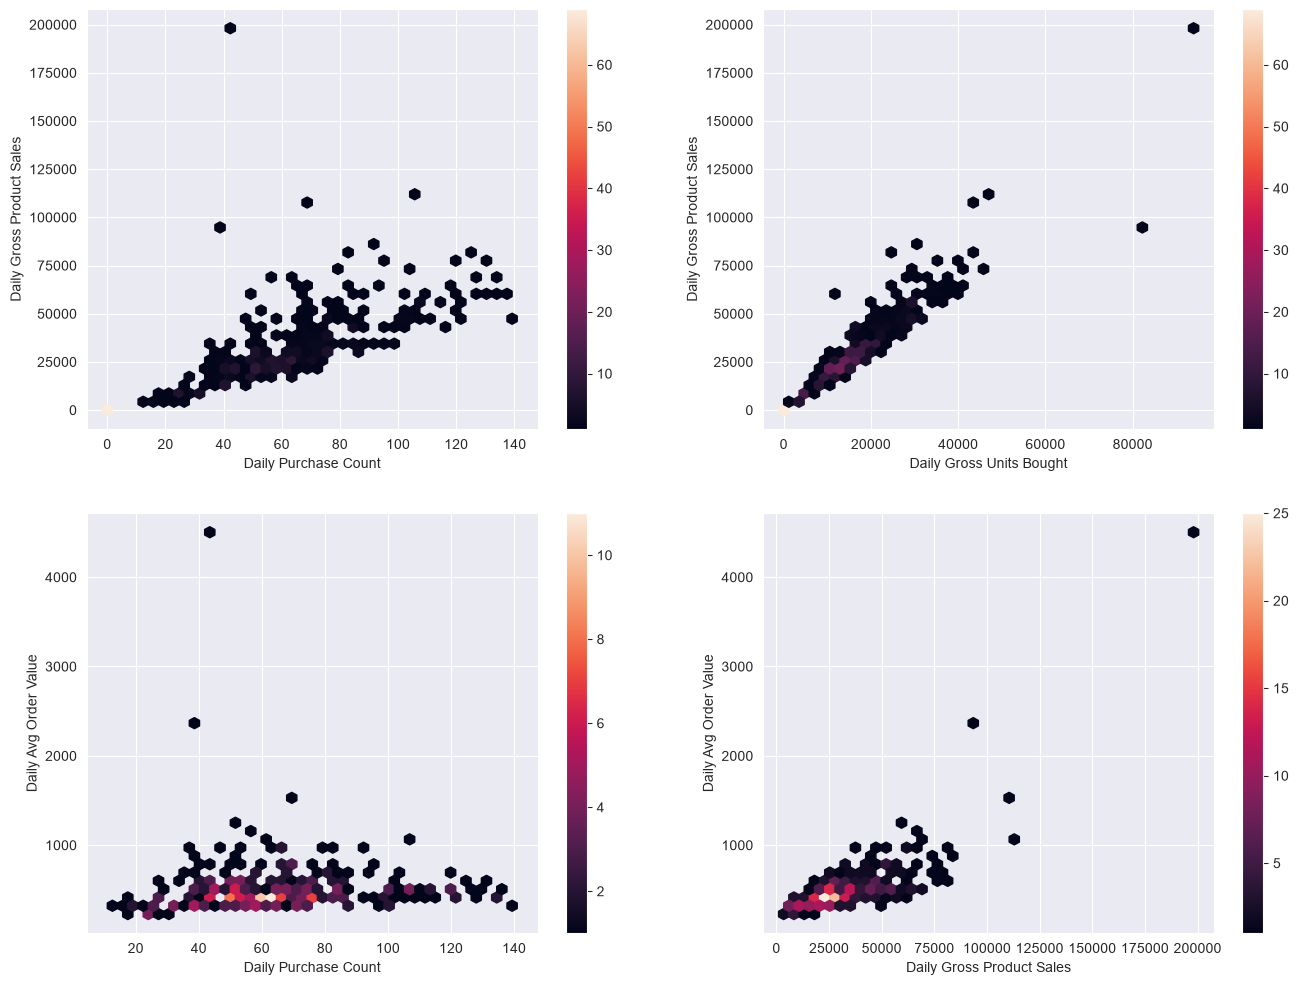

In [31]:
fig, axes =plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0][0]
hexbin1 = ax1.hexbin(
    x=daily_purchase_count,
    y=daily_gross_sales,
    gridsize=40,
    mincnt=1
)
ax1.set_xlabel('Daily Purchase Count')
ax1.set_ylabel('Daily Gross Product Sales')

ax2 = axes[0][1]
hexbin2 = ax2.hexbin(
    x=daily_gross_units_bought,
    y=daily_gross_sales,
    gridsize=40,
    mincnt=1
)
ax2.set_xlabel('Daily Gross Units Bought')
ax2.set_ylabel('Daily Gross Product Sales')

ax3 = axes[1][0]
hexbin3 = ax3.hexbin(
    x=daily_purchase_count,
    y=daily_avg_order_value,
    gridsize=40,
    mincnt=1
)
ax3.set_xlabel('Daily Purchase Count')
ax3.set_ylabel('Daily Avg Order Value')

ax4 = axes[1][1]
hexbin4 = ax4.hexbin(
    x=daily_gross_sales,
    y=daily_avg_order_value,
    gridsize=40,
    mincnt=1
)
ax4.set_xlabel('Daily Gross Product Sales')
ax4.set_ylabel('Daily Avg Order Value')

plt.colorbar(hexbin1)
plt.colorbar(hexbin2)
plt.colorbar(hexbin3)
plt.colorbar(hexbin4)

Days with higher purchase counts generally generate more sales, but the relationship is not tight since some days that have a high amount of purchases generate ordinary sales because their orders are small in basket-size and/or have cheap items, and some days that have a small amount of purchases generate high sales because they have a large basket-size and/or expensive items.

The total units bought per day by far has the strongest relationship with daily gross sales.

Daily sales variations seem more affected by changes in order value rather than the amount of orders in that day.

Daily purchase count and daily average order value are unrelated linearly and have a weak positive monotonic relationship, meaning that busy days do not necessarily attract more-valued orders.

## Products Performance

In [32]:
products = (
    purchase_rows.groupby('StockCode').agg(
        ProductName=('Description', 'first'),
        Purchases=('InvoiceNo', 'nunique'),
        TotalUnits=('Quantity', 'sum'),
        AvgUnitsPerOrder=('Quantity', lambda x: x.sum() / purchase_rows.loc[x.index, 'InvoiceNo'].nunique()),
        MedianPrice=('UnitPrice', 'median'),
        TotalValue=('LineValue', 'sum'),
        AvgValuePerOrder=('LineValue', lambda x: x.sum() / purchase_rows.loc[x.index, 'InvoiceNo'].nunique()),
        FirstPurchaseDate=('InvoiceDate', 'first'),
        FirstPurchaseDaysAgo=('InvoiceDate', lambda x: (latest_timestamp - x.min()).days),
        LastPurchase=('InvoiceDate', 'last'),
        LastPurchaseDaysAgo=('InvoiceDate', lambda x: (latest_timestamp - x.max()).days),
        LifeSpan=('InvoiceDate', lambda x: (x.max() - x.min()).days),
        UniqueCustomers=('CustomerID', 'nunique'),
        PurchasesPerCustomer=('CustomerID', lambda x: purchase_rows.loc[x.index, 'InvoiceNo'].nunique() / x.nunique() if x.notna().any() else 0),
    )
    .reset_index()
)

In [33]:
products_cancellations = df.groupby('StockCode')['Cancelled'].sum()
products['Cancellations'] = products['StockCode'].map(products_cancellations)
products_cancellation_rates = df.groupby('StockCode')['Cancelled'].mean()
products['CancellationRate'] = products['StockCode'].map(products_cancellation_rates)

In [34]:
products.describe()

,Purchases,TotalUnits,AvgUnitsPerOrder,MedianPrice,TotalValue,AvgValuePerOrder,FirstPurchaseDate,FirstPurchaseDaysAgo,LastPurchase,LastPurchaseDaysAgo,LifeSpan,UniqueCustomers,PurchasesPerCustomer,Cancellations,CancellationRate
count,3775.000000,3775.000000,3775.000000,3775.000000,3775.00000,3775.000000,3775,3775.000000,3775,3775.000000,3775.000000,3775.000000,3775.000000,3775.000000,3775.000000
mean,136.973510,1477.349934,30.479696,3.494612,2720.80387,60.845749,2011-01-23 01:24:13.764238,319.942517,2011-10-26 10:46:26.034437,43.621987,275.882119,70.493510,2.155309,2.301457,0.017578
min,1.000000,1.000000,1.000000,0.040000,0.42000,0.420000,2010-12-01 08:26:00,0.000000,2010-12-01 09:41:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,68.000000,2.760263,1.000000,148.86000,6.387841,2010-12-01 14:32:00,324.000000,2011-11-13 11:55:00,0.000000,183.000000,9.000000,1.301632,0.000000,0.000000
50%,70.000000,415.000000,5.621469,2.080000,734.79000,11.045806,2010-12-05 13:17:00,368.000000,2011-12-07 13:46:00,1.000000,354.000000,37.000000,1.687500,1.000000,0.003106
75%,172.000000,1463.000000,10.406703,4.130000,2340.53000,17.853166,2011-01-19 01:58:30,372.000000,2011-12-09 10:03:00,26.000000,371.000000,96.500000,2.250000,2.000000,0.017669
max,2265.000000,80995.000000,80995.000000,165.000000,174484.74000,168469.600000,2011-12-09 09:15:00,373.000000,2011-12-09 12:50:00,373.000000,373.000000,881.000000,86.000000,181.000000,0.750000
std,195.947058,3644.984592,1318.339126,6.865533,7219.11744,2742.240679,NaN,94.641471,NaN,88.570900,123.745076,91.067312,2.531100,5.881198,0.045537


In [35]:
log_transformed_products = np.log1p(products.select_dtypes(include='number'))

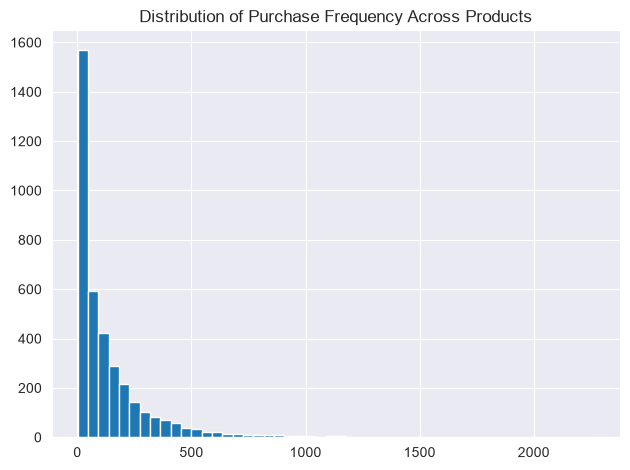

In [132]:
plt.hist(products['Purchases'], bins=50)
plt.title('Distribution of Purchase Frequency Across Products')
plt.tight_layout()

The distribution of purchase counts across products is right skewed, implying that most products have low purchase frequency.

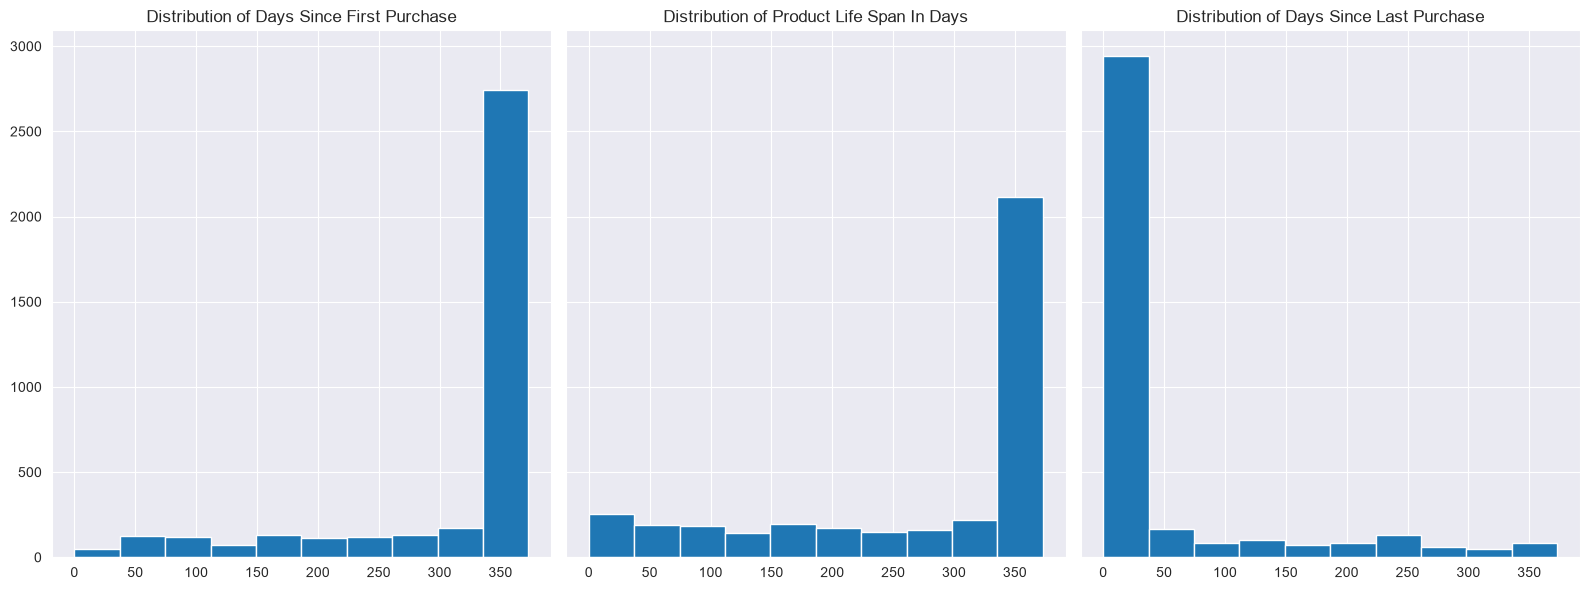

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)

ax1 = axes[0]
ax1.hist(products['FirstPurchaseDaysAgo'])
ax1.set_title('Distribution of Days Since First Purchase')

ax2 = axes[1]
ax2.hist(products['LifeSpan'])
ax2.set_title('Distribution of Product Life Span In Days')

ax3 = axes[2]
ax3.hist(products['LastPurchaseDaysAgo'])
ax3.set_title('Distribution of Days Since Last Purchase')

plt.tight_layout()

In [37]:
percent(len(products[products['LifeSpan'] >= 350]), len(products))

'51.89%'

~51.89% of products have long life spans (350+ days).

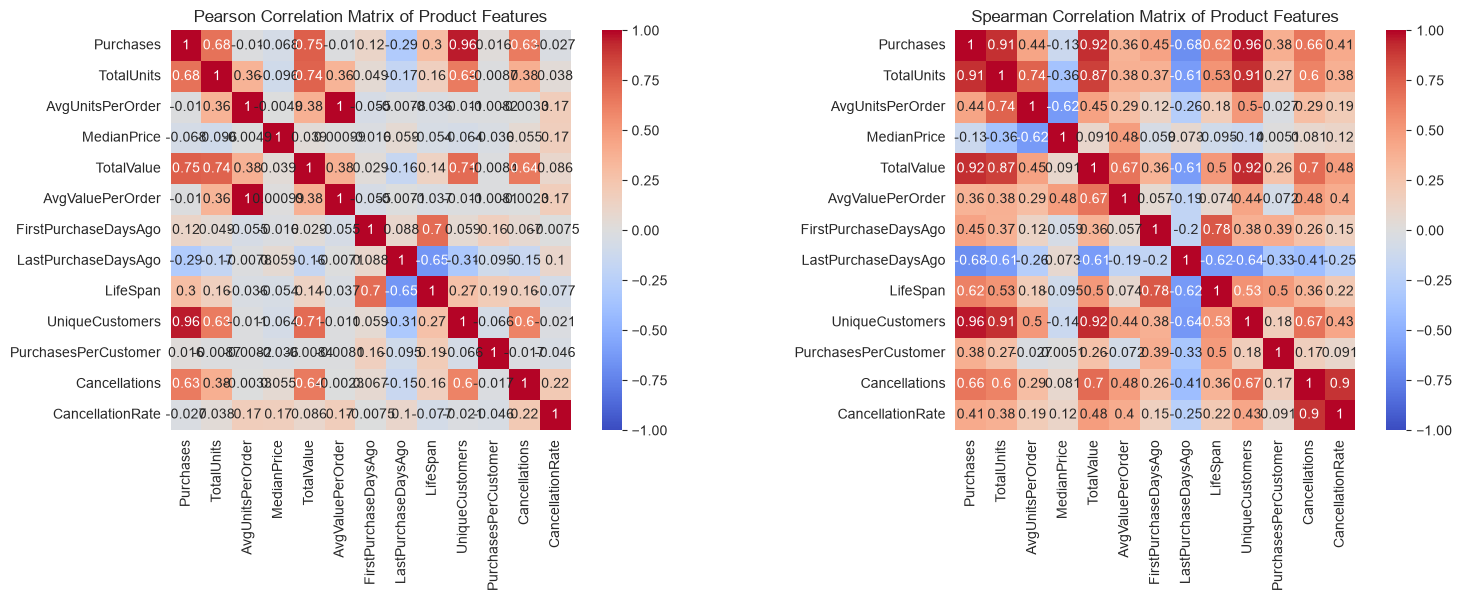

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sns.heatmap(
    products.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax1
)
ax1.set_title('Pearson Correlation Matrix of Product Features')

ax2 = axes[1]
sns.heatmap(
    products.corr(method='spearman', numeric_only=True),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax2
)
ax2.set_title('Spearman Correlation Matrix of Product Features')

plt.tight_layout()

Products with longer life spans naturally drive more over-all activity.

Purchase count per product has its strongest association with unique identified-customer count. This suggests that frequently purchased products generally achieve higher purchase counts through broader customer reach.

The Pearson correlation between average units per order and average value per order on the product level is approximately 1, while the Spearman correlation is only 0.29. This big difference is likely because of the extreme values in quantity.

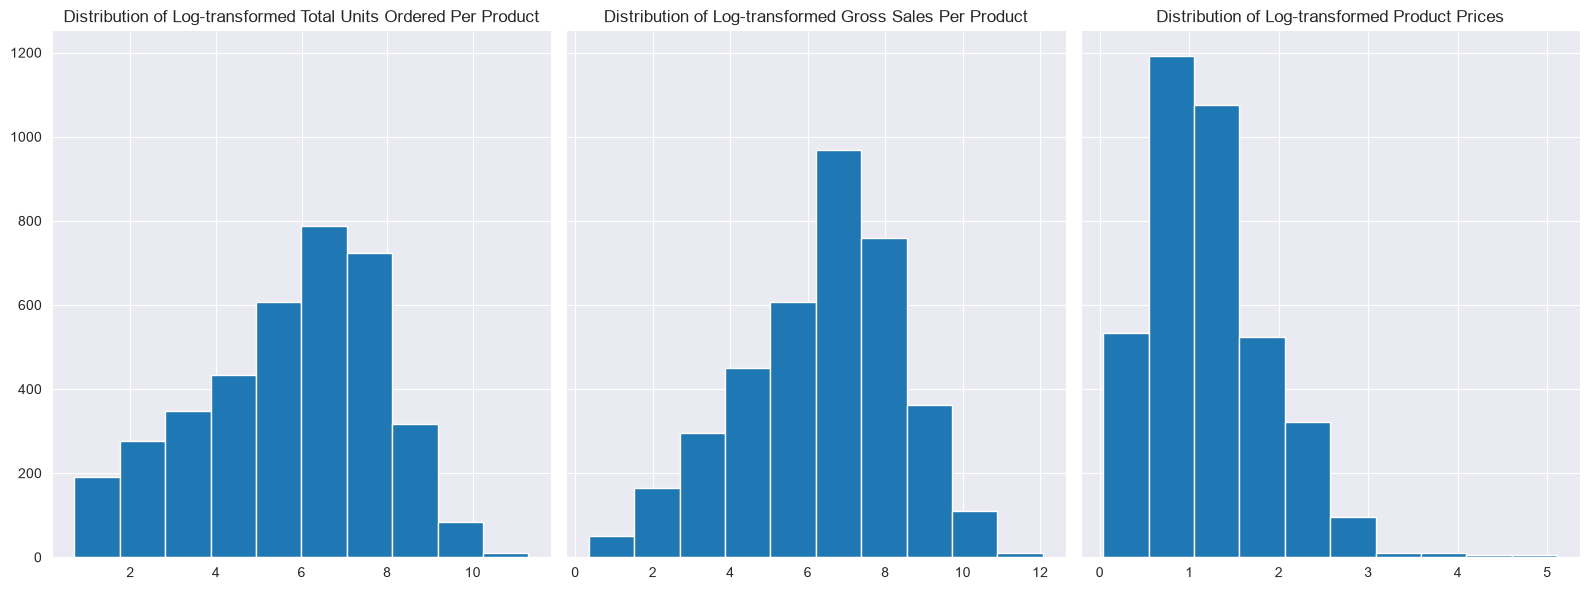

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

ax1 = axes[0]
ax1.hist(log_transformed_products['TotalUnits'])
ax1.set_title('Distribution of Log-transformed Total Units Ordered Per Product')

ax2 = axes[1]
ax2.hist(log_transformed_products['TotalValue'])
ax2.set_title('Distribution of Log-transformed Gross Sales Per Product')

ax3 = axes[2]
ax3.hist(log_transformed_products['MedianPrice'])
ax3.set_title('Distribution of Log-transformed Product Prices')

plt.tight_layout()

All log-transformed product features show a bell-shaped distribution, which means that the original distribution is heavily right-skewed.

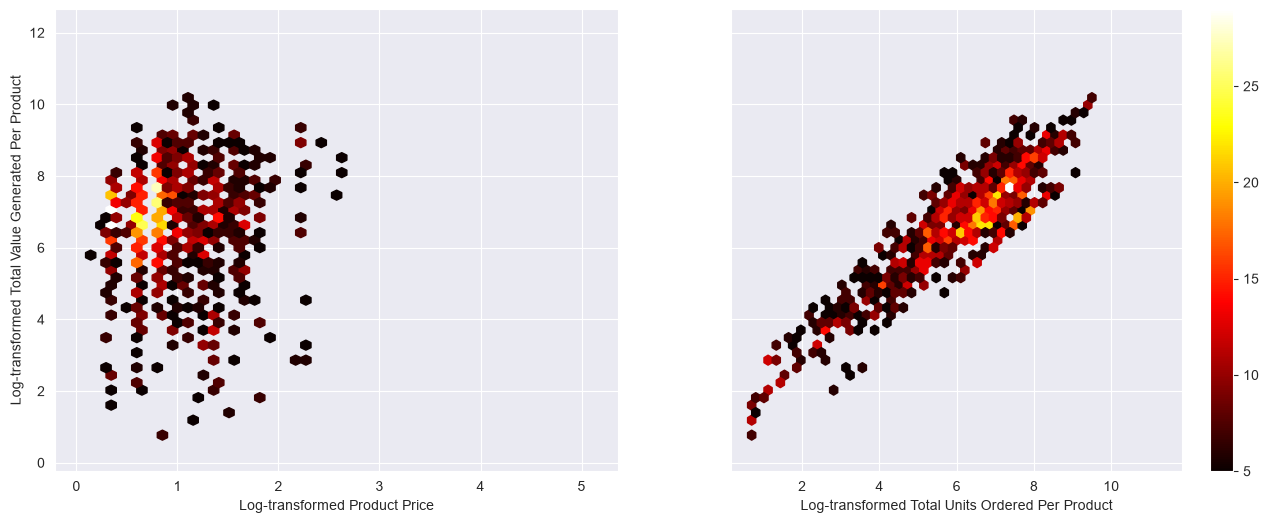

In [40]:
fig, axes =plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax1 = axes[0]
hexbin1 = ax1.hexbin(
    x=log_transformed_products['MedianPrice'],
    y=log_transformed_products['TotalValue'],
    gridsize=50,
    mincnt=5,
    cmap='hot'
)
ax1.set_xlabel('Log-transformed Product Price')
ax1.set_ylabel('Log-transformed Total Value Generated Per Product')

ax2 = axes[1]
hexbin2 = ax2.hexbin(
    x=log_transformed_products['TotalUnits'],
    y=log_transformed_products['TotalValue'],
    gridsize=50,
    mincnt=5,
    cmap='hot'
)
ax2.set_xlabel('Log-transformed Total Units Ordered Per Product')

plt.colorbar(hexbin2)

Gross sales per product are much more affected by units ordered rather than how expensive the product is.

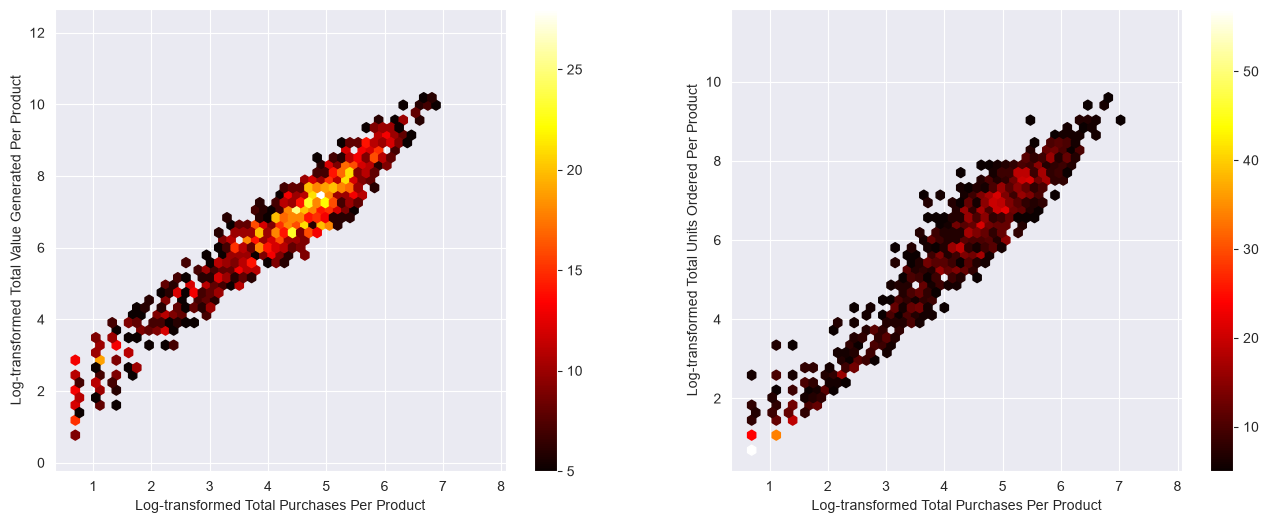

In [41]:
fig, axes =plt.subplots(1, 2, figsize=(16, 6), sharex=True)

ax1 = axes[0]
hexbin1 = ax1.hexbin(
    x=log_transformed_products['Purchases'],
    y=log_transformed_products['TotalValue'],
    gridsize=50,
    mincnt=5,
    cmap='hot'
)
ax1.set_xlabel('Log-transformed Total Purchases Per Product')
ax1.set_ylabel('Log-transformed Total Value Generated Per Product')

ax2 = axes[1]
hexbin2 = ax2.hexbin(
    x=log_transformed_products['Purchases'],
    y=log_transformed_products['TotalUnits'],
    gridsize=50,
    mincnt=5,
    cmap='hot'
)
ax2.set_xlabel('Log-transformed Total Purchases Per Product')
ax2.set_ylabel('Log-transformed Total Units Ordered Per Product')

plt.colorbar(hexbin1)
plt.colorbar(hexbin2)

Gross sales, purchase count, and total units ordered per product are all linearly related.

In [42]:
products['TotalValue'].describe()

count      3775.00000
mean       2720.80387
std        7219.11744
min           0.42000
25%         148.86000
50%         734.79000
75%        2340.53000
max      174484.74000
Name: TotalValue, dtype: float64

In [43]:
products['TotalValue'].quantile([0.75, 0.9, 0.95, 0.99, 0.999])

0.750     2340.53000
0.900     6747.99000
0.950    11495.47200
0.990    28085.05160
0.999    95507.17728
Name: TotalValue, dtype: float64

### High-Value Products vs. Low-Value Products:

Let's divide products unto two parts, top 20% value-generating products and the rest 80% of products.

In [44]:
high_value_products = products[products['TotalValue'] >= products['TotalValue'].quantile(0.8)]
low_value_products = products[products['TotalValue'] < products['TotalValue'].quantile(0.8)]

In [45]:
print('Gross Sales Percentage of High-Value Products:', percent(high_value_products['TotalValue'].sum(), summary.loc['gross_sales']))
print('Gross Sales Percentage of Low-Value Products:', percent(low_value_products['TotalValue'].sum(), summary.loc['gross_sales']))

Gross Sales Percentage of High-Value Products: 78.2%
Gross Sales Percentage of Low-Value Products: 21.8%


The top 20% of products represent ~78.2% of total value, and the rest of the 80% represent 21.8% of total value. This shows that products have the Pareto principle.

In [46]:
log_transformed_high_value_products = np.log1p(high_value_products.select_dtypes(include='number'))
log_transformed_low_value_products = np.log1p(low_value_products.select_dtypes(include='number'))

Text(0.5, 1.0, 'Distribution of Days Since Last Purchase (Low-Value)')

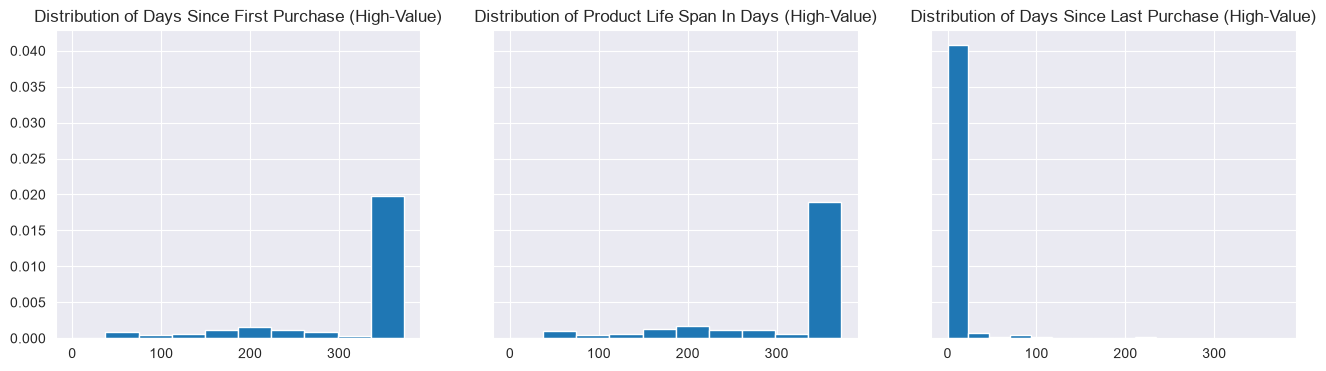

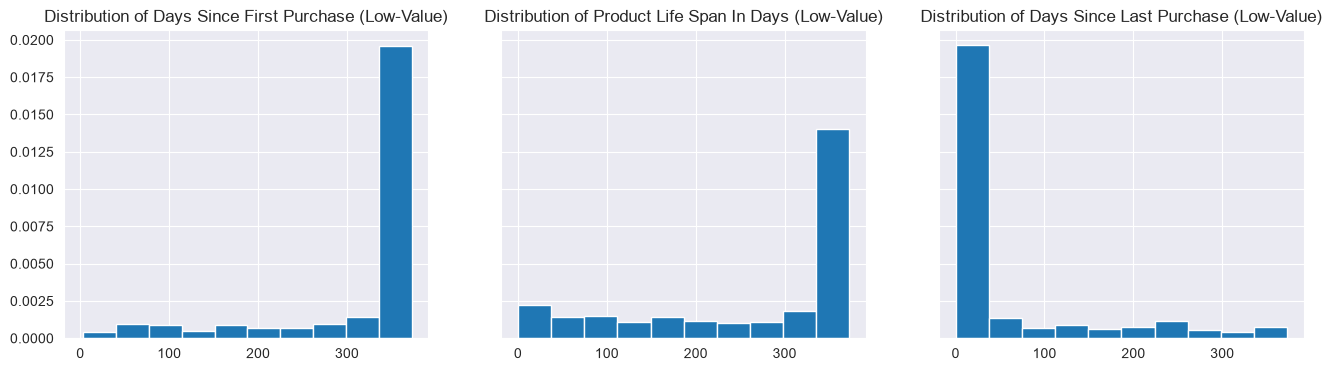

In [47]:
fig, axes1 = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

ax1 = axes1[0]
ax1.hist(high_value_products['FirstPurchaseDaysAgo'], bins=10, density=True)
ax1.set_title('Distribution of Days Since First Purchase (High-Value)')

ax2 = axes1[1]
ax2.hist(high_value_products['LifeSpan'], bins=10, density=True)
ax2.set_title('Distribution of Product Life Span In Days (High-Value)')

ax3 = axes1[2]
ax3.hist(high_value_products['LastPurchaseDaysAgo'], bins=10, density=True)
ax3.set_title('Distribution of Days Since Last Purchase (High-Value)')

fig, axes2 = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

ax1 = axes2[0]
ax1.hist(low_value_products['FirstPurchaseDaysAgo'], bins=10, density=True)
ax1.set_title('Distribution of Days Since First Purchase (Low-Value)')

ax2 = axes2[1]
ax2.hist(low_value_products['LifeSpan'], bins=10, density=True)
ax2.set_title('Distribution of Product Life Span In Days (Low-Value)')

ax3 = axes2[2]
ax3.hist(low_value_products['LastPurchaseDaysAgo'], bins=10, density=True)
ax3.set_title('Distribution of Days Since Last Purchase (Low-Value)')

High-value products have much more active products with higher product life spans and more recent purchases, which is because high-value products are inherently more active. This explains the high linear correlation between days since first purchase and life spans of products.

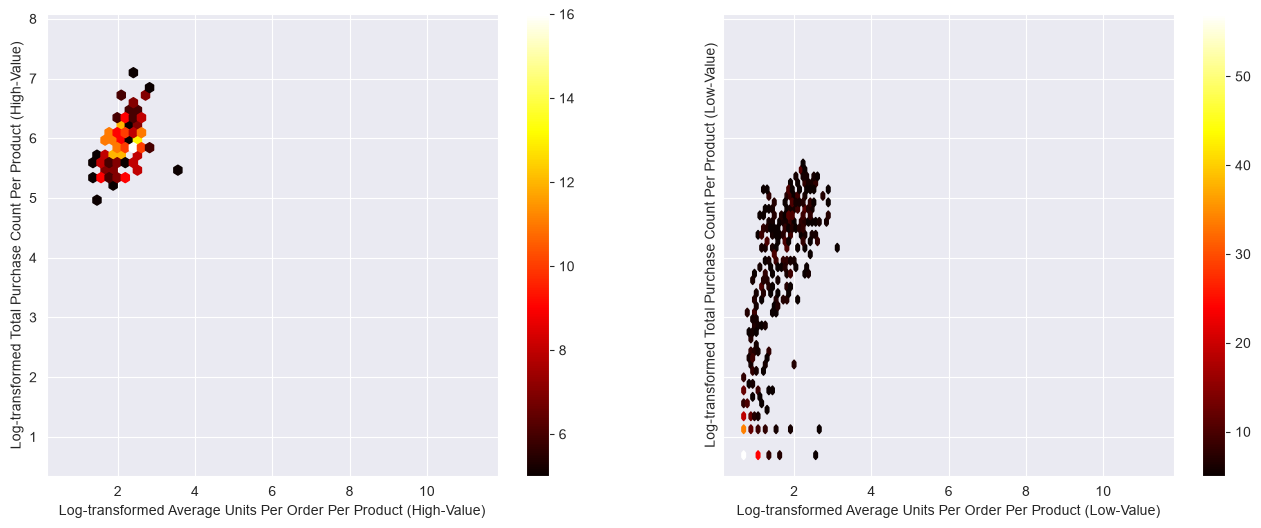

In [48]:
fig, axes =plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

ax1 = axes[0]
hexbin1 = ax1.hexbin(
    x=log_transformed_high_value_products['AvgUnitsPerOrder'],
    y=log_transformed_high_value_products['Purchases'],
    gridsize=50,
    mincnt=5,
    cmap='hot'
)
ax1.set_xlabel('Log-transformed Average Units Per Order Per Product (High-Value)')
ax1.set_ylabel('Log-transformed Total Purchase Count Per Product (High-Value)')

ax2 = axes[1]
hexbin2 = ax2.hexbin(
    x=log_transformed_low_value_products['AvgUnitsPerOrder'],
    y=log_transformed_low_value_products['Purchases'],
    gridsize=50,
    mincnt=5,
    cmap='hot'
)
ax2.set_xlabel('Log-transformed Average Units Per Order Per Product (Low-Value)')
ax2.set_ylabel('Log-transformed Total Purchase Count Per Product (Low-Value)')

plt.colorbar(hexbin1)
plt.colorbar(hexbin2)

The relationship between average units per order and total purchase count in low-value products seems to be much more concentrated in the low values, while the high-value products is more broad.

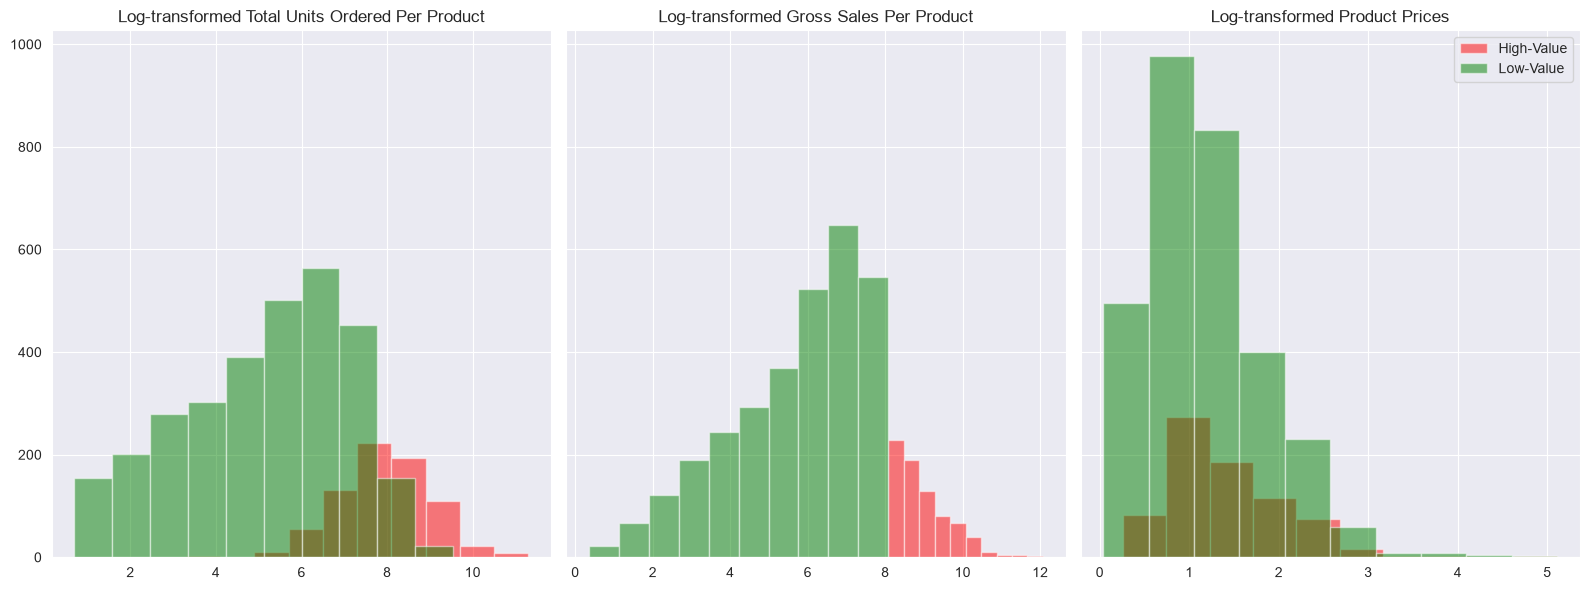

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

ax1 = axes[0]
ax1.hist(log_transformed_high_value_products['TotalUnits'], color='red', label='High-Value', alpha=0.5)
ax1.hist(log_transformed_low_value_products['TotalUnits'], color='green', label='Low-Value', alpha=0.5)
ax1.set_title('Log-transformed Total Units Ordered Per Product')

ax2 = axes[1]
ax2.hist(log_transformed_high_value_products['TotalValue'], color='red', label='High-Value', alpha=0.5)
ax2.hist(log_transformed_low_value_products['TotalValue'], color='green', label='Low-Value', alpha=0.5)
ax2.set_title('Log-transformed Gross Sales Per Product')

ax3 = axes[2]
ax3.hist(log_transformed_high_value_products['MedianPrice'], color='red', label='High-Value', alpha=0.5)
ax3.hist(log_transformed_low_value_products['MedianPrice'], color='green', label='Low-Value', alpha=0.5)
ax3.set_title('Log-transformed Product Prices')

plt.legend()

plt.tight_layout()

The distributions of price in both high-value and low-value products are almost the same shape. Meaning product price has little relevance towards gross sales across products.

The high-value products generally have greater total unit sales than the low-value products, supporting the claim that sales volume is an important characteristic of high-value products. However, the distributions of units overlap considerably, showing that volume alone does not differeniate between the two product categories; other product factors also contribute.

In [50]:
high_value_stockcodes_purchase_rows = purchase_rows[purchase_rows['StockCode'].isin(high_value_products['StockCode'])]
high_value_stockcodes_monthly_gross_sales = high_value_stockcodes_purchase_rows.groupby('Month')['LineValue'].sum()

low_value_stockcodes_purchase_rows = purchase_rows[purchase_rows['StockCode'].isin(low_value_products['StockCode'])]
low_value_stockcodes_monthly_gross_sales = low_value_stockcodes_purchase_rows.groupby('Month')['LineValue'].sum()

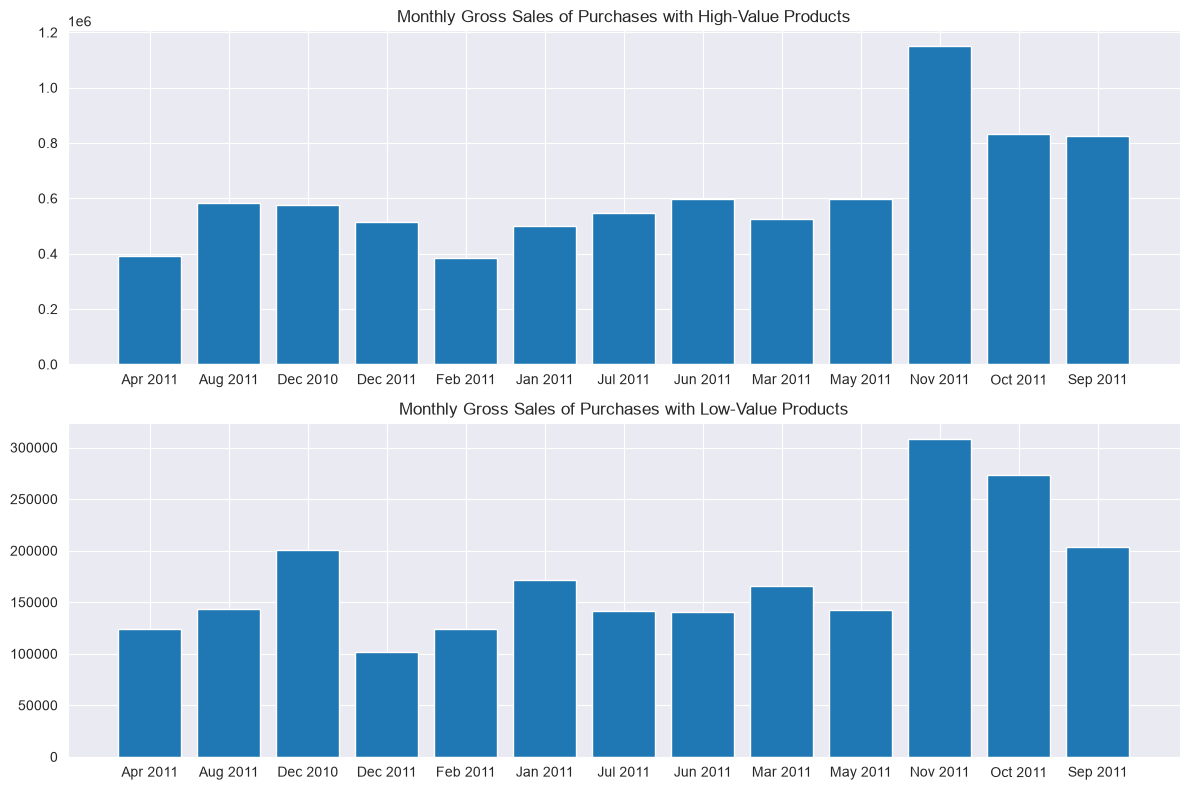

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax1 = axes[0]
ax1.bar(high_value_stockcodes_monthly_gross_sales.index, high_value_stockcodes_monthly_gross_sales)
ax1.set_title('Monthly Gross Sales of Purchases with High-Value Products')

ax2 = axes[1]
ax2.bar(low_value_stockcodes_monthly_gross_sales.index, low_value_stockcodes_monthly_gross_sales)
ax2.set_title('Monthly Gross Sales of Purchases with Low-Value Products')

plt.tight_layout()

### Product Rankings

In [52]:
top10_products_by_value = products.nlargest(10, 'TotalValue')
top10_products_by_value

,StockCode,ProductName,Purchases,TotalUnits,AvgUnitsPerOrder,MedianPrice,TotalValue,AvgValuePerOrder,FirstPurchaseDate,FirstPurchaseDaysAgo,LastPurchase,LastPurchaseDaysAgo,LifeSpan,UniqueCustomers,PurchasesPerCustomer,Cancellations,CancellationRate
1302,22423,REGENCY CAKESTAND 3 TIER,1988,13879,6.981388,12.75,174484.74,87.768984,2010-12-01 12:27:00,373,2011-12-09 10:23:00,0,372,881,2.256527,181,0.082348
2457,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,80995.000000,2.08,168469.60,168469.600000,2011-12-09 09:15:00,0,2011-12-09 09:15:00,0,0,1,1.000000,1,0.500000
3292,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2265,37952,16.755850,2.95,106471.28,47.007188,2010-12-01 08:26:00,373,2011-12-09 11:34:00,0,373,856,2.646028,42,0.017692
2653,47566,PARTY BUNTING,1685,18295,10.857567,4.95,99504.33,59.053015,2010-12-03 11:27:00,371,2011-12-09 10:23:00,0,370,708,2.379944,20,0.011587
3276,85099B,JUMBO BAG RED RETROSPOT,2089,48474,23.204404,2.08,94340.05,45.160388,2010-12-01 09:57:00,373,2011-12-09 10:26:00,0,373,635,3.289764,44,0.020408
2012,23166,MEDIUM CERAMIC TOP STORAGE JAR,247,78033,315.923077,1.25,81700.92,330.772955,2011-01-18 10:01:00,325,2011-12-09 10:03:00,0,325,138,1.789855,10,0.038462
1934,23084,RABBIT NIGHT LIGHT,994,30788,30.973843,2.08,66964.99,67.369205,2011-05-10 14:20:00,212,2011-12-09 12:31:00,0,212,450,2.208889,15,0.014272
998,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1160,19355,16.685345,2.95,64952.29,55.993353,2010-12-01 09:00:00,373,2011-12-09 12:19:00,0,373,613,1.892333,10,0.008264
3114,84879,ASSORTED COLOUR BIRD ORNAMENT,1455,36461,25.059107,1.69,59094.93,40.615072,2010-12-01 08:34:00,373,2011-12-09 12:31:00,0,373,678,2.146018,12,0.007995
2804,79321,CHILLI LIGHTS,661,10306,15.591528,5.75,54117.76,81.872557,2010-12-01 09:58:00,373,2011-12-09 12:20:00,0,373,205,3.224390,6,0.008876


In [53]:
top10_purchased_products = products.nlargest(10, 'Purchases')
top10_purchased_products

,StockCode,ProductName,Purchases,TotalUnits,AvgUnitsPerOrder,MedianPrice,TotalValue,AvgValuePerOrder,FirstPurchaseDate,FirstPurchaseDaysAgo,LastPurchase,LastPurchaseDaysAgo,LifeSpan,UniqueCustomers,PurchasesPerCustomer,Cancellations,CancellationRate
3292,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2265,37952,16.755850,2.95,106471.28,47.007188,2010-12-01 08:26:00,373,2011-12-09 11:34:00,0,373,856,2.646028,42,0.017692
3276,85099B,JUMBO BAG RED RETROSPOT,2089,48474,23.204404,2.08,94340.05,45.160388,2010-12-01 09:57:00,373,2011-12-09 10:26:00,0,373,635,3.289764,44,0.020408
1302,22423,REGENCY CAKESTAND 3 TIER,1988,13879,6.981388,12.75,174484.74,87.768984,2010-12-01 12:27:00,373,2011-12-09 10:23:00,0,372,881,2.256527,181,0.082348
2653,47566,PARTY BUNTING,1685,18295,10.857567,4.95,99504.33,59.053015,2010-12-03 11:27:00,371,2011-12-09 10:23:00,0,370,708,2.379944,20,0.011587
169,20725,LUNCH BAG RED RETROSPOT,1565,19553,12.493930,1.65,36042.01,23.030038,2010-12-01 09:37:00,373,2011-12-09 12:23:00,0,373,532,2.941729,44,0.026846
3114,84879,ASSORTED COLOUR BIRD ORNAMENT,1455,36461,25.059107,1.69,59094.93,40.615072,2010-12-01 08:34:00,373,2011-12-09 12:31:00,0,373,678,2.146018,12,0.007995
1101,22197,POPCORN HOLDER,1392,56921,40.891523,0.85,51354.02,36.892256,2010-12-01 10:19:00,373,2011-12-09 12:19:00,0,373,407,3.420147,50,0.033875
1585,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1385,7493,5.410108,4.95,38158.39,27.551184,2010-12-13 15:13:00,360,2011-12-09 10:03:00,0,360,640,2.164062,74,0.050238
431,21212,PACK OF 72 RETROSPOT CAKE CASES,1320,36419,27.590152,0.55,21259.10,16.105379,2010-12-01 09:37:00,373,2011-12-09 10:23:00,0,373,635,2.078740,15,0.010830
1268,22383,LUNCH BAG SUKI DESIGN,1284,12552,9.775701,1.65,22542.44,17.556417,2010-12-01 11:29:00,373,2011-12-09 10:23:00,0,372,434,2.958525,21,0.015590


In [54]:
top10_products_by_units = products.nlargest(10, 'TotalUnits')
top10_products_by_units

,StockCode,ProductName,Purchases,TotalUnits,AvgUnitsPerOrder,MedianPrice,TotalValue,AvgValuePerOrder,FirstPurchaseDate,FirstPurchaseDaysAgo,LastPurchase,LastPurchaseDaysAgo,LifeSpan,UniqueCustomers,PurchasesPerCustomer,Cancellations,CancellationRate
2457,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,80995.000000,2.08,168469.60,168469.600000,2011-12-09 09:15:00,0,2011-12-09 09:15:00,0,0,1,1.000000,1,0.500000
2012,23166,MEDIUM CERAMIC TOP STORAGE JAR,247,78033,315.923077,1.25,81700.92,330.772955,2011-01-18 10:01:00,325,2011-12-09 10:03:00,0,325,138,1.789855,10,0.038462
1101,22197,POPCORN HOLDER,1392,56921,40.891523,0.85,51354.02,36.892256,2010-12-01 10:19:00,373,2011-12-09 12:19:00,0,373,407,3.420147,50,0.033875
2856,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,535,55047,102.891589,0.29,13841.85,25.872617,2010-12-02 10:09:00,372,2011-12-09 10:03:00,0,371,307,1.742671,5,0.009225
3276,85099B,JUMBO BAG RED RETROSPOT,2089,48474,23.204404,2.08,94340.05,45.160388,2010-12-01 09:57:00,373,2011-12-09 10:26:00,0,373,635,3.289764,44,0.020408
3292,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2265,37952,16.755850,2.95,106471.28,47.007188,2010-12-01 08:26:00,373,2011-12-09 11:34:00,0,373,856,2.646028,42,0.017692
3114,84879,ASSORTED COLOUR BIRD ORNAMENT,1455,36461,25.059107,1.69,59094.93,40.615072,2010-12-01 08:34:00,373,2011-12-09 12:31:00,0,373,678,2.146018,12,0.007995
431,21212,PACK OF 72 RETROSPOT CAKE CASES,1320,36419,27.590152,0.55,21259.10,16.105379,2010-12-01 09:37:00,373,2011-12-09 10:23:00,0,373,635,2.078740,15,0.010830
1934,23084,RABBIT NIGHT LIGHT,994,30788,30.973843,2.08,66964.99,67.369205,2011-05-10 14:20:00,212,2011-12-09 12:31:00,0,212,450,2.208889,15,0.014272
1366,22492,MINI PAINT SET VINTAGE,380,26633,70.086842,0.65,16937.82,44.573211,2010-12-01 08:45:00,373,2011-12-08 16:29:00,0,372,213,1.784038,10,0.025641


In [55]:
top10_products_by_units['ProductName']

2457           PAPER CRAFT , LITTLE BIRDIE
2012        MEDIUM CERAMIC TOP STORAGE JAR
1101                        POPCORN HOLDER
2856     WORLD WAR 2 GLIDERS ASSTD DESIGNS
3276               JUMBO BAG RED RETROSPOT
3292    WHITE HANGING HEART T-LIGHT HOLDER
3114         ASSORTED COLOUR BIRD ORNAMENT
431        PACK OF 72 RETROSPOT CAKE CASES
1934                    RABBIT NIGHT LIGHT
1366               MINI PAINT SET VINTAGE 
Name: ProductName, dtype: str

## Identified-Customer Behavior Analysis

In [56]:
print('Percentage of Rows with Missing Customers:', percent(len(purchase_rows[purchase_rows['CustomerID'].isna()]), len(purchase_rows)))
print('Percentage of Orders with Missing Customers:', percent(len(orders[orders['CustomerID'].isna()]), len(orders)))
print('Value Percentage of Orders with Missing Customers:', percent(orders[orders['CustomerID'].isna()]['TotalValue'].sum(), orders['TotalValue'].sum()))

Percentage of Rows with Missing Customers: 24.9%
Percentage of Orders with Missing Customers: 6.93%
Value Percentage of Orders with Missing Customers: 14.7%


Orders with missing customers generally tend to be smaller in size. They also represent 14.7% of valuec despite representing 24.9% of total rows.

In [57]:
identified_purchase_rows = purchase_rows[purchase_rows['CustomerID'].notna()]

In [58]:
customers = (
    identified_purchase_rows.groupby('CustomerID').agg(
        UnitsOrdered=('Quantity', 'sum'),
        AvgUnits=('Quantity', 'mean'),
        AvgUnitsPerOrder=('Quantity', lambda x: x.sum() / identified_purchase_rows.loc[x.index, 'InvoiceNo'].nunique()),
        AvgPrice=('UnitPrice', 'mean'),
        TotalValue=('LineValue', 'sum'),
        Purchases=('InvoiceNo', 'nunique'),
        RepeatBuyer=('InvoiceNo', lambda x: x.nunique() >= 2),
        AvgOrderValue=('LineValue', lambda x: x.sum() / identified_purchase_rows.loc[x.index, 'InvoiceNo'].nunique()),
        FirstPurchaseDate=('InvoiceDate', 'first'),
        FirstPurchaseDaysAgo=('InvoiceDate', lambda x: (latest_timestamp - x.min()).days),
        LastPurchase=('InvoiceDate', 'last'),
        LastPurchaseDaysAgo=('InvoiceDate', lambda x: (latest_timestamp - x.max()).days),
        LifeSpan=('InvoiceDate', lambda x: (x.max() - x.min()).days)
    )
    .reset_index()
)

In [59]:
customers_cancellations = df.groupby('CustomerID')['Cancelled'].sum()
customers['Cancellations'] = customers['CustomerID'].map(customers_cancellations)
customers_cancellation_rates = df.groupby('CustomerID')['Cancelled'].mean()
customers['CancellationRate'] = customers['CustomerID'].map(customers_cancellation_rates)

In [60]:
customers.describe()

,CustomerID,UnitsOrdered,AvgUnits,AvgUnitsPerOrder,AvgPrice,TotalValue,Purchases,AvgOrderValue,FirstPurchaseDate,FirstPurchaseDaysAgo,LastPurchase,LastPurchaseDaysAgo,LifeSpan,Cancellations,CancellationRate
count,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000,4334,4334.000000,4334,4334.000000,4334.000000,4334.000000,4334.000000
mean,15299.251731,1189.975542,45.677395,256.299107,3.450277,2021.473616,4.245962,417.009550,2011-04-30 17:02:24.711582,222.311029,2011-09-08 07:38:29.487771,91.703046,130.286341,1.947393,0.022984
min,12346.000000,1.000000,1.000000,1.000000,0.122500,3.750000,1.000000,3.750000,2010-12-01 08:26:00,0.000000,2010-12-01 09:53:00,0.000000,0.000000,0.000000,0.000000
25%,13812.250000,160.000000,6.028009,93.500000,2.147769,305.560000,1.000000,178.190000,2011-01-17 11:13:15,112.000000,2011-07-20 10:55:00,17.000000,0.000000,0.000000,0.000000
50%,15297.500000,379.000000,10.000000,162.000000,2.825933,668.125000,2.000000,290.435000,2011-04-05 09:52:30,248.000000,2011-10-20 09:48:30,50.000000,92.000000,0.000000,0.000000
75%,16778.750000,991.750000,14.719828,273.000000,3.689205,1631.622500,5.000000,425.811667,2011-08-19 10:11:30,326.000000,2011-11-22 11:05:45,142.000000,252.000000,1.000000,0.017857
max,18287.000000,196844.000000,74215.000000,74215.000000,434.650000,279138.020000,206.000000,84236.250000,2011-12-09 12:16:00,373.000000,2011-12-09 12:50:00,373.000000,373.000000,222.000000,0.833333
std,1721.994109,5042.964341,1205.077348,1316.513642,8.861031,8907.501378,7.634989,1800.923299,NaN,117.870423,NaN,100.177047,132.089593,7.209054,0.060656


In [119]:
log_transformed_customers = np.log1p(customers.select_dtypes('number'))

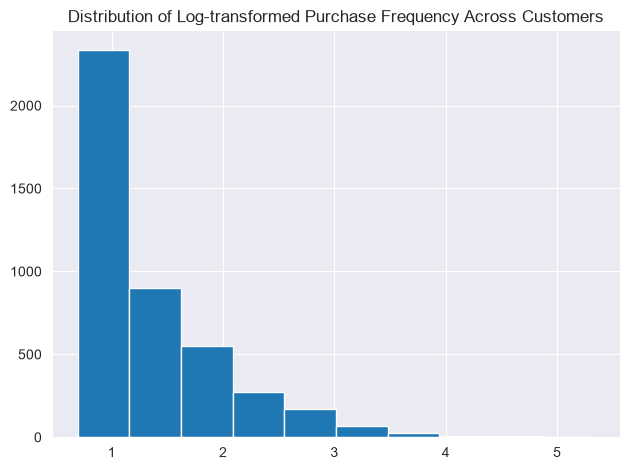

In [123]:
plt.hist(log_transformed_customers['Purchases'])
plt.title('Distribution of Log-transformed Purchase Frequency Across Customers')
plt.tight_layout()

The distribution of log-transformed purchase frequency is right-skewed, meaning that the original distribution is even more right-skewed. This implies that most customers order at low frequency.

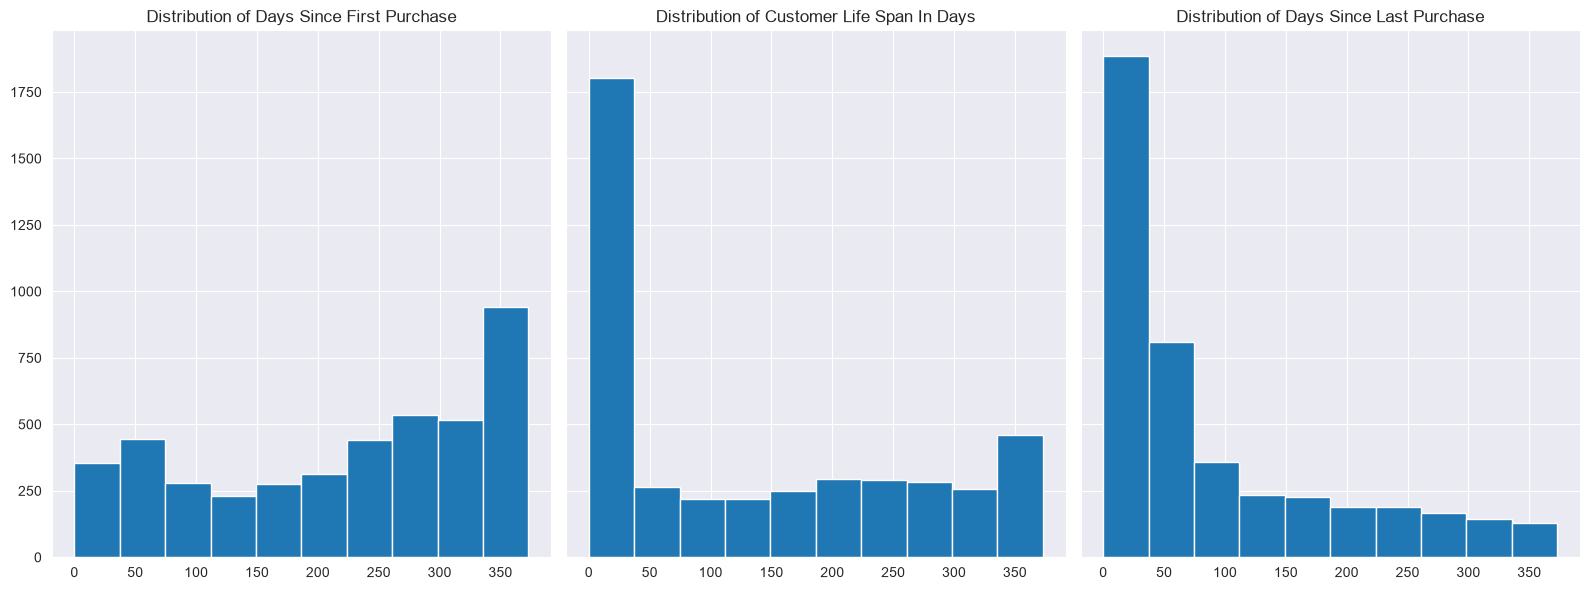

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)

ax1 = axes[0]
ax1.hist(customers['FirstPurchaseDaysAgo'])
ax1.set_title('Distribution of Days Since First Purchase')

ax2 = axes[1]
ax2.hist(customers['LifeSpan'])
ax2.set_title('Distribution of Customer Life Span In Days')

ax3 = axes[2]
ax3.hist(customers['LastPurchaseDaysAgo'])
ax3.set_title('Distribution of Days Since Last Purchase')

plt.tight_layout()

Although most customers have been active recently, their observed lifespans remain relatively short because most customers made their first purchase on a more recent date.

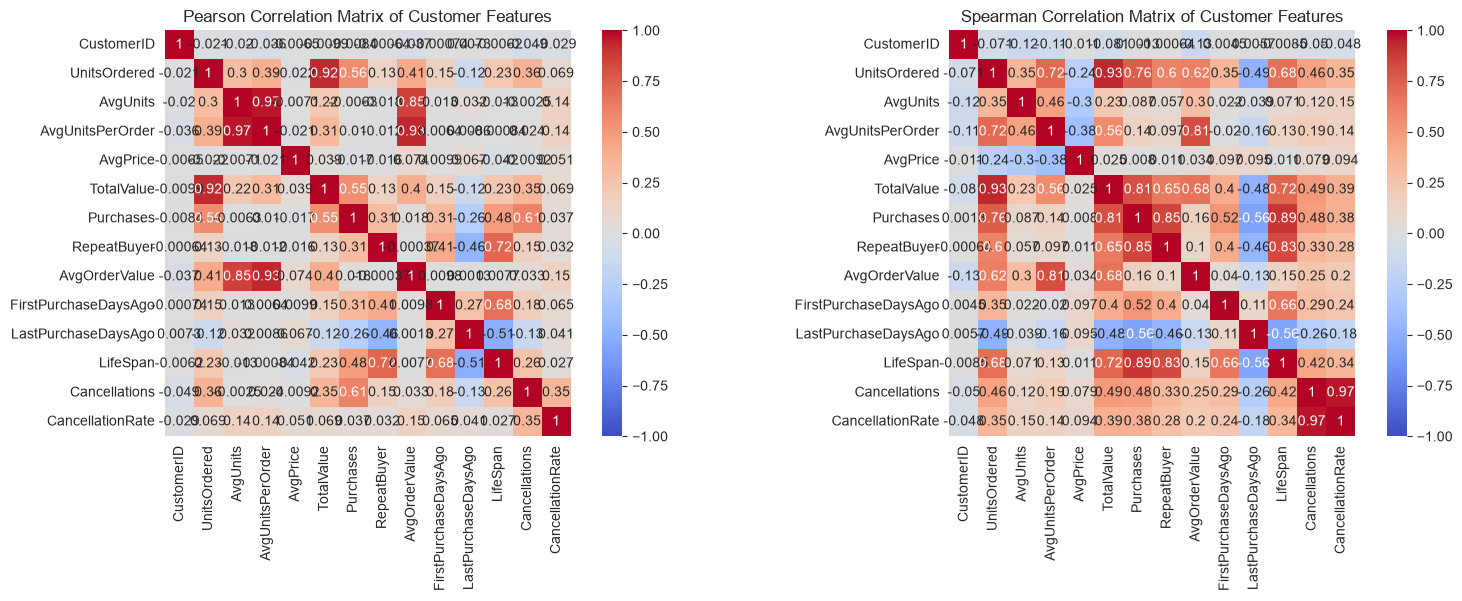

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sns.heatmap(
    customers.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax1
)
ax1.set_title('Pearson Correlation Matrix of Customer Features')

ax2 = axes[1]
sns.heatmap(
    customers.corr(method='spearman', numeric_only=True),
    annot=True,
    cmap='coolwarm',
    square=True,
    vmin=-1,
    vmax=1,
    ax=ax2
)
ax2.set_title('Spearman Correlation Matrix of Customer Features')

plt.tight_layout()

Total value, purchase count, and total units ordered are very closely related.

The strong correlation between customer life span and the three features named above (total value, purchase count, and total units ordered) indicates that high-life span customers tend to drive more activity.

In [ ]:
customers_repeat_buyers = customers[customers['RepeatBuyer']]
print("Repeat-purchase rate:", percent(len(customers_repeat_buyers), len(customers)))

Repeat-purchase rate: 65.27%


In [ ]:
print("Percentage of Repeat-Buyers' Value", percent(customers_repeat_buyers['TotalValue'].sum(), customers['TotalValue'].sum()))

Percentage of Repeat-Buyers' Value 92.82%


Despite representing 65.27% of customers, Repeat-buyers represent 92.82% of total customer value.

In [64]:
high_value_customers = customers[customers['TotalValue'] >= customers['TotalValue'].quantile(0.8)]
low_value_customers = customers[customers['TotalValue'] < customers['TotalValue'].quantile(0.8)]

In [65]:
print('Gross Sales Percentage of High-Value Customers:', percent(high_value_customers['TotalValue'].sum(), identified_purchase_rows['LineValue'].sum()))
print('Gross Sales Percentage of Low-Value Customers:', percent(low_value_customers['TotalValue'].sum(), identified_purchase_rows['LineValue'].sum()))

Gross Sales Percentage of High-Value Customers: 74.54%
Gross Sales Percentage of Low-Value Customers: 25.46%


The top 20% of identified customers represent ~74.54% of total value, and the rest of the 80% represent 25.46% of total value. This shows that customers follow the Pareto principle.

## Cancellation Analysis

In [66]:
summary

gross_sales                          10271034.61
net_sales                             9792310.43
gross_units_ordered                      5576996
net_units_ordered                        5304966
purchase_count                             19773
avg_order_value                       519.447459
identified_customer_count                   4334
cancellation_count                          3422
cancelled_value                        478724.18
cancelled_units                           272030
avg_cancellation_value                -139.89602
cancellation_count_rate                   17.31%
cancellation_value_rate                    4.66%
cancellation_units_rate                    4.88%
cancellation_avg_order_value_rate         26.93%
dtype: object

17.31% of purchases were cancelled, but only accounted for 4.66% of total value, also the average cancellation value is -139.89, its absolute value (139.89) is ~73% less than the average order value (519.45). This means that cancellations likely happen with low-value orders (assuming that cancellations are done on whole orders).

The rates of value cancelled (4.66%) and units cancelled (4.88%) is very close. This supports the hypothesis of units being the primary driver of value, even in cancellations.

In [67]:
cancelled_orders.describe()

,CustomerID,TotalValue,AvgUnitPrice,HighestPrice,TotalUnits,AvgUnits,UniqueProducts,InvoiceDate,DayOfMonth
count,3383.000000,3422.000000,3422.000000,3422.000000,3422.000000,3422.000000,3422.000000,3422,3422.000000
mean,15122.522317,-139.896020,5.600338,6.961341,-79.494448,-59.614698,2.522794,2011-06-18 08:21:51.461134,14.882525
min,12346.000000,-168469.600000,0.030000,0.030000,-80995.000000,-80995.000000,1.000000,2010-12-01 09:49:00,1.000000
25%,13619.000000,-33.437500,1.950000,2.100000,-12.000000,-6.000000,1.000000,2011-03-11 09:41:15,7.000000
50%,15005.000000,-15.050000,3.572143,4.250000,-4.000000,-2.000000,1.000000,2011-06-21 17:16:00,14.000000
75%,16608.000000,-7.500000,6.100000,8.500000,-2.000000,-1.000000,3.000000,2011-09-29 13:26:45,22.000000
max,18282.000000,-0.390000,295.000000,295.000000,-1.000000,-1.000000,101.000000,2011-12-09 11:58:00,31.000000
std,1717.183425,3204.507519,13.087930,13.670196,1897.210964,1885.108681,3.849922,NaN,8.634458


In [68]:
cancelled_orders.sort_values(by='TotalValue').head(5)

,InvoiceNo,CustomerID,TotalValue,AvgUnitPrice,HighestPrice,TotalUnits,AvgUnits,UniqueProducts,InvoiceDate,Date,Month,DayOfMonth,Weekday,Country
3418,581484,16446.0,-168469.60,2.080000,2.08,-80995,-80995.000000,1,2011-12-09 09:27:00,2011-12-09,Dec 2011,9,Friday,United Kingdom
413,541433,12346.0,-77183.60,1.040000,1.04,-74215,-74215.000000,1,2011-01-18 10:17:00,2011-01-18,Jan 2011,18,Tuesday,United Kingdom
1160,550456,15749.0,-22998.40,3.160000,6.75,-9014,-1802.800000,5,2011-04-18 13:08:00,2011-04-18,Apr 2011,18,Monday,United Kingdom
2706,570556,16029.0,-11816.64,2.534167,3.39,-6480,-540.000000,8,2011-10-11 11:10:00,2011-10-11,Oct 2011,11,Tuesday,United Kingdom
2079,562375,14911.0,-4345.10,3.264839,12.50,-2270,-73.225806,31,2011-08-04 14:46:00,2011-08-04,Aug 2011,4,Thursday,EIRE


In [69]:
orders.sort_values(by='TotalValue', ascending=False).head(5)

,InvoiceNo,CustomerID,TotalValue,AvgUnitPrice,HighestPrice,TotalUnits,AvgUnits,UniqueProducts,InvoiceDate,Date,Month,DayOfMonth,Weekday,Country
19737,581483,16446.0,168469.60,2.080000,2.08,80995,80995.000000,1,2011-12-09 09:15:00,2011-12-09,Dec 2011,9,Friday,United Kingdom
2107,541431,12346.0,77183.60,1.040000,1.04,74215,74215.000000,1,2011-01-18 10:01:00,2011-01-18,Jan 2011,18,Tuesday,United Kingdom
16754,574941,NaN,52940.94,4.939505,16.09,14149,140.089109,101,2011-11-07 17:42:00,2011-11-07,Nov 2011,7,Monday,United Kingdom
17403,576365,NaN,50653.91,4.742525,14.95,13956,140.969697,99,2011-11-14 17:55:00,2011-11-14,Nov 2011,14,Monday,United Kingdom
8632,556444,15098.0,38970.00,649.500000,649.50,60,60.000000,1,2011-06-10 15:28:00,2011-06-10,Jun 2011,10,Friday,United Kingdom


Cancellations contain some quantity extreme values which are affecting the summary.

Let's try excluding the extreme values for sensitivity analysis.

In [70]:
nonextreme_orders = orders[np.abs(orders['TotalValue']) < 70000]
nonextreme_cancelled_orders = cancelled_orders[np.abs(cancelled_orders['TotalValue']) < 70000]

In [71]:
nonextreme_summary = pd.Series(
    {
        'gross_sales':nonextreme_orders['TotalValue'].sum(),
        'net_sales':nonextreme_orders['TotalValue'].sum() - -nonextreme_cancelled_orders['TotalValue'].sum(),
        'gross_units_ordered':nonextreme_orders['TotalUnits'].sum(),
        'net_units_ordered':nonextreme_orders['TotalUnits'].sum() - -nonextreme_cancelled_orders['TotalUnits'].sum(),
        'purchase_count':len(nonextreme_orders),
        'avg_order_value':nonextreme_orders['TotalValue'].mean(),
        'identified_customer_count':nonextreme_orders['CustomerID'].nunique(),
        'cancellation_count':len(nonextreme_cancelled_orders),
        'cancelled_value':-nonextreme_cancelled_orders['TotalValue'].sum(),
        'cancelled_units':-nonextreme_cancelled_orders['TotalUnits'].sum(),
        'avg_cancellation_value':nonextreme_cancelled_orders['TotalValue'].mean(),
        'cancellation_count_rate':percent(len(nonextreme_cancelled_orders), len(nonextreme_orders)),
        'cancellation_value_rate':percent(-nonextreme_cancelled_orders['TotalValue'].sum(), nonextreme_orders['TotalValue'].sum()),
        'cancellation_units_rate':percent(-nonextreme_cancelled_orders['TotalUnits'].sum(), nonextreme_orders['TotalUnits'].sum()),
        'cancellation_avg_order_value_rate':percent(-nonextreme_cancelled_orders['TotalValue'].mean(), nonextreme_orders['TotalValue'].mean())
    }
)

In [72]:
summary

gross_sales                          10271034.61
net_sales                             9792310.43
gross_units_ordered                      5576996
net_units_ordered                        5304966
purchase_count                             19773
avg_order_value                       519.447459
identified_customer_count                   4334
cancellation_count                          3422
cancelled_value                        478724.18
cancelled_units                           272030
avg_cancellation_value                -139.89602
cancellation_count_rate                   17.31%
cancellation_value_rate                    4.66%
cancellation_units_rate                    4.88%
cancellation_avg_order_value_rate         26.93%
dtype: object

In [73]:
nonextreme_summary

gross_sales                          10025381.41
net_sales                             9792310.43
gross_units_ordered                      5421786
net_units_ordered                        5304966
purchase_count                             19771
avg_order_value                        507.07508
identified_customer_count                   4333
cancellation_count                          3420
cancelled_value                        233070.98
cancelled_units                           116820
avg_cancellation_value                -68.149409
cancellation_count_rate                    17.3%
cancellation_value_rate                    2.32%
cancellation_units_rate                    2.15%
cancellation_avg_order_value_rate         13.44%
dtype: object

The rates of value and units cancelled went down by about half (2.32% and 2.15% from 4.66% and 4.88% respectively). The rate of average cancellation value and average order value has also decreased by almost half.

### Cancellations Conditions

#### Time-trends & Cancellations

In [74]:
daily_abs_cancellation_value = np.abs(cancelled_orders.groupby('Date')['TotalValue'].sum()).reindex(date_index, fill_value=0)
rolling_7day_abs_cancellation_value = daily_abs_cancellation_value.rolling(window=7, min_periods=1).mean()

monthly_abs_cancellation_value = np.abs(cancelled_orders.groupby('Month')['TotalValue'].sum()).reindex(cancelled_orders['Month'].unique())

Text(0, 0.5, 'Cancellation Value')

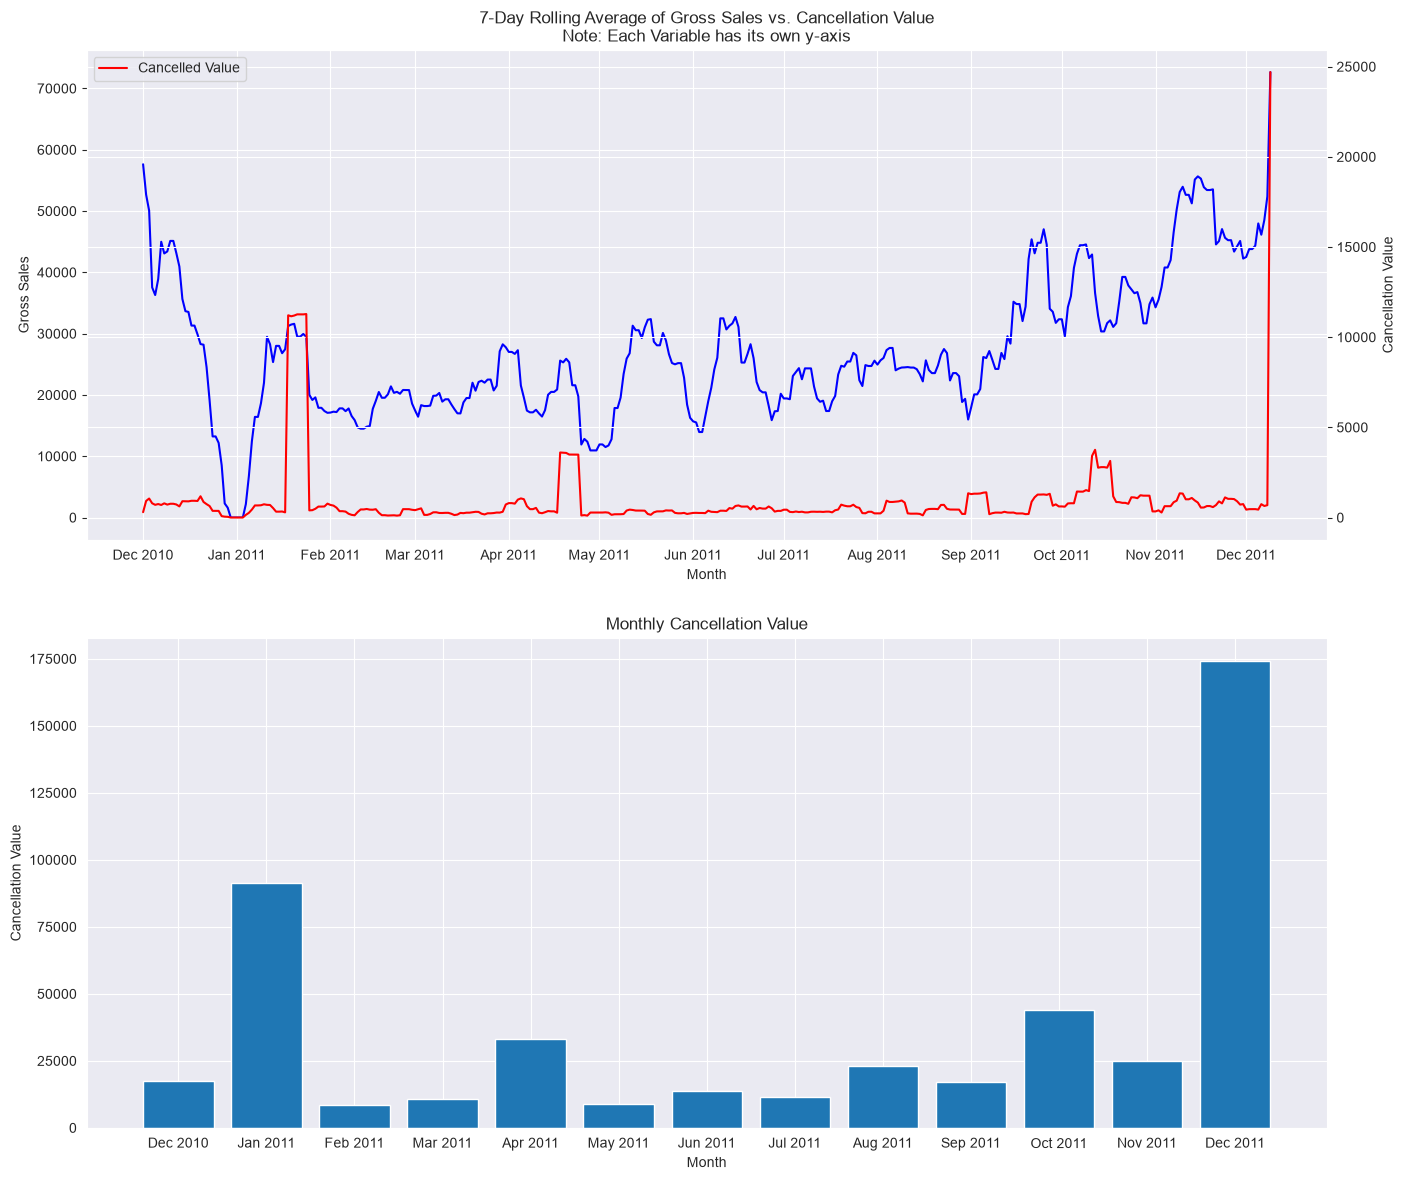

In [75]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

ax1 = axes[0]
ax1.plot(rolling_7day_gross_sales, c='blue', label='Gross Sales')
ax1.set_ylabel("Gross Sales")

ax2 = ax1.twinx()
ax2.plot(rolling_7day_abs_cancellation_value, c='red', label='Cancelled Value')
ax2.set_ylabel("Cancellation Value")

date_ticks = pd.date_range(start="2010-12-01", end="2011-12-01", freq="MS")
ax1.set_xticks(date_ticks)
ax1.set_xticklabels([date.strftime("%b %Y") for date in date_ticks])
ax1.set_xlabel("Month")
ax1.set_title("7-Day Rolling Average of Gross Sales vs. Cancellation Value\nNote: Each Variable has its own y-axis")
ax2.legend()

ax3 = axes[1]
ax3.bar(monthly_abs_cancellation_value.index, monthly_abs_cancellation_value)
ax3.set_title("Monthly Cancellation Value")
ax3.set_xlabel("Month")
ax3.set_ylabel("Cancellation Value")

In the 7-day rolling plot, most cancellation value is concentrated in certain sharp-spikes, mainly January, April, October, and the final recorded days in december 2011. This is supported by the monthly plot.

In [76]:
daily_cancellation_count = cancelled_orders.groupby('Date')['InvoiceNo'].count().reindex(date_index, fill_value=0)
rolling_7day_cancellation_count = daily_cancellation_count.rolling(window=7, min_periods=1).mean()

monthly_cancellation_count = np.abs(cancelled_orders.groupby('Month')['InvoiceNo'].count()).reindex(cancelled_orders['Month'].unique())

Text(0, 0.5, 'Cancellation Count')

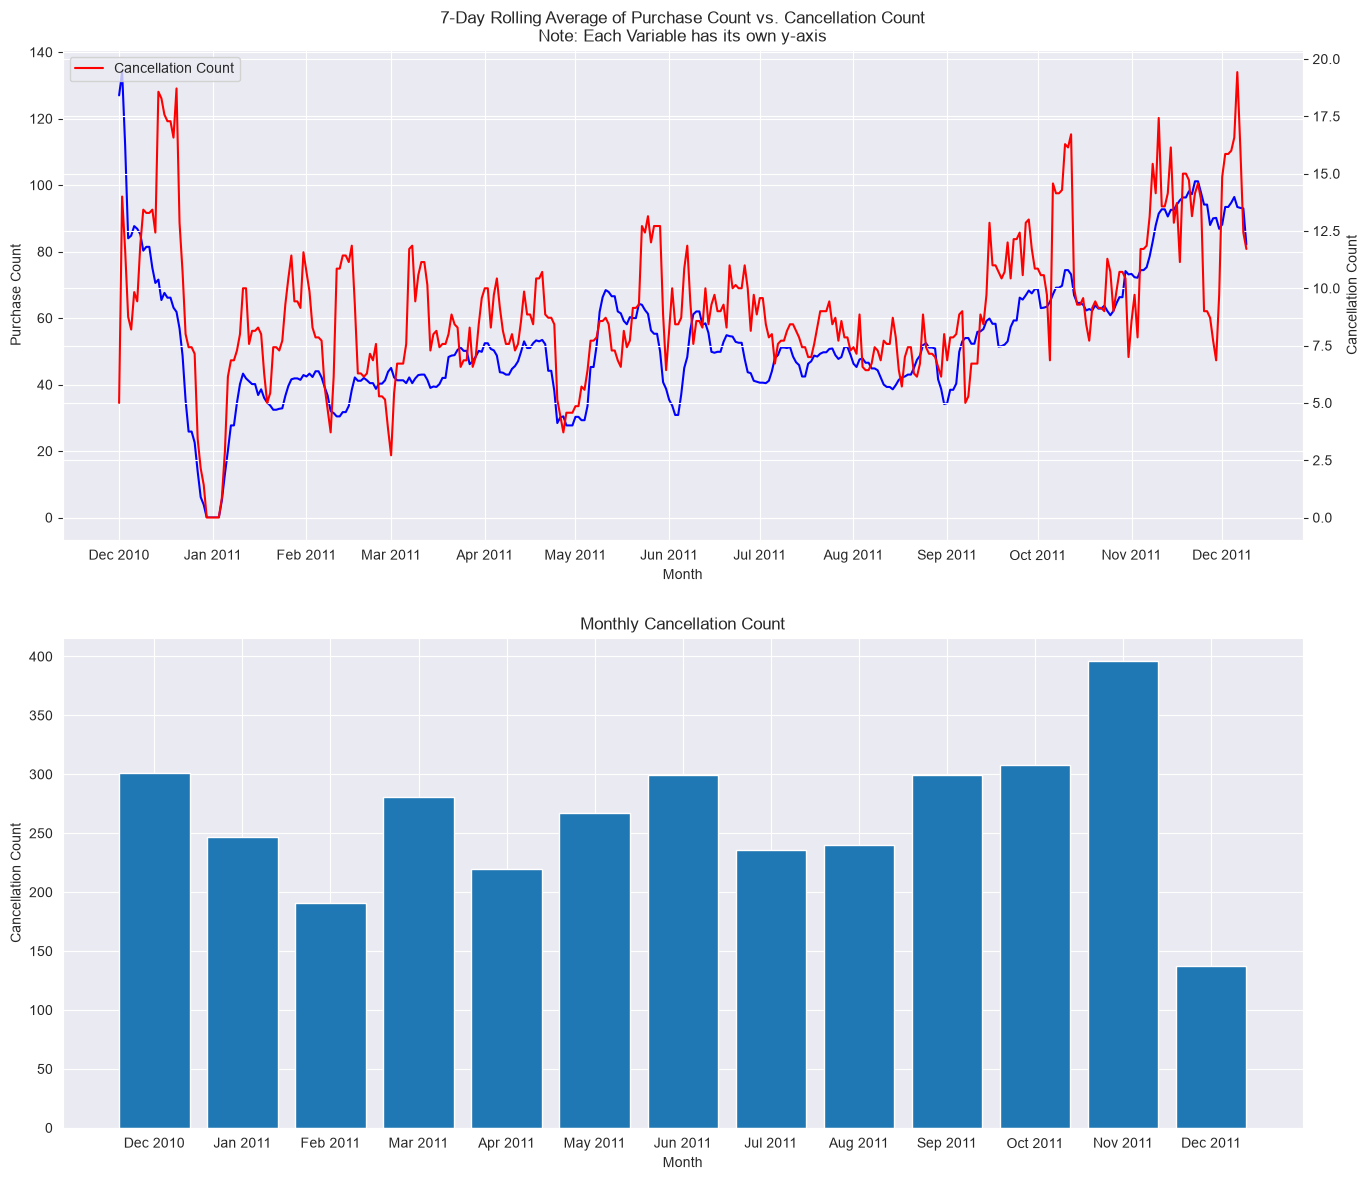

In [112]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

ax1 = axes[0]
ax1.plot(rolling_7day_purchase_count, c='blue', label='Purchase Count')
ax1.set_ylabel("Purchase Count")

ax2 = ax1.twinx()
ax2.plot(rolling_7day_cancellation_count, c='red', label='Cancellation Count')
ax2.set_ylabel("Cancellation Count")

date_ticks = pd.date_range(start="2010-12-01", end="2011-12-01", freq="MS")
ax1.set_xticks(date_ticks)
ax1.set_xticklabels([date.strftime("%b %Y") for date in date_ticks])
ax1.set_xlabel("Month")
ax1.set_title("7-Day Rolling Average of Purchase Count vs. Cancellation Count\nNote: Each Variable has its own y-axis")
ax2.legend()

ax3 = axes[1]
ax3.bar(monthly_cancellation_count.index, monthly_cancellation_count)
ax3.set_title("Monthly Cancellation Count")
ax3.set_xlabel("Month")
ax3.set_ylabel("Cancellation Count")

Unlike value, cancellation count generally follows purchase count. Though cancellations are more volatile which is usual.

#### Products & Cancellations

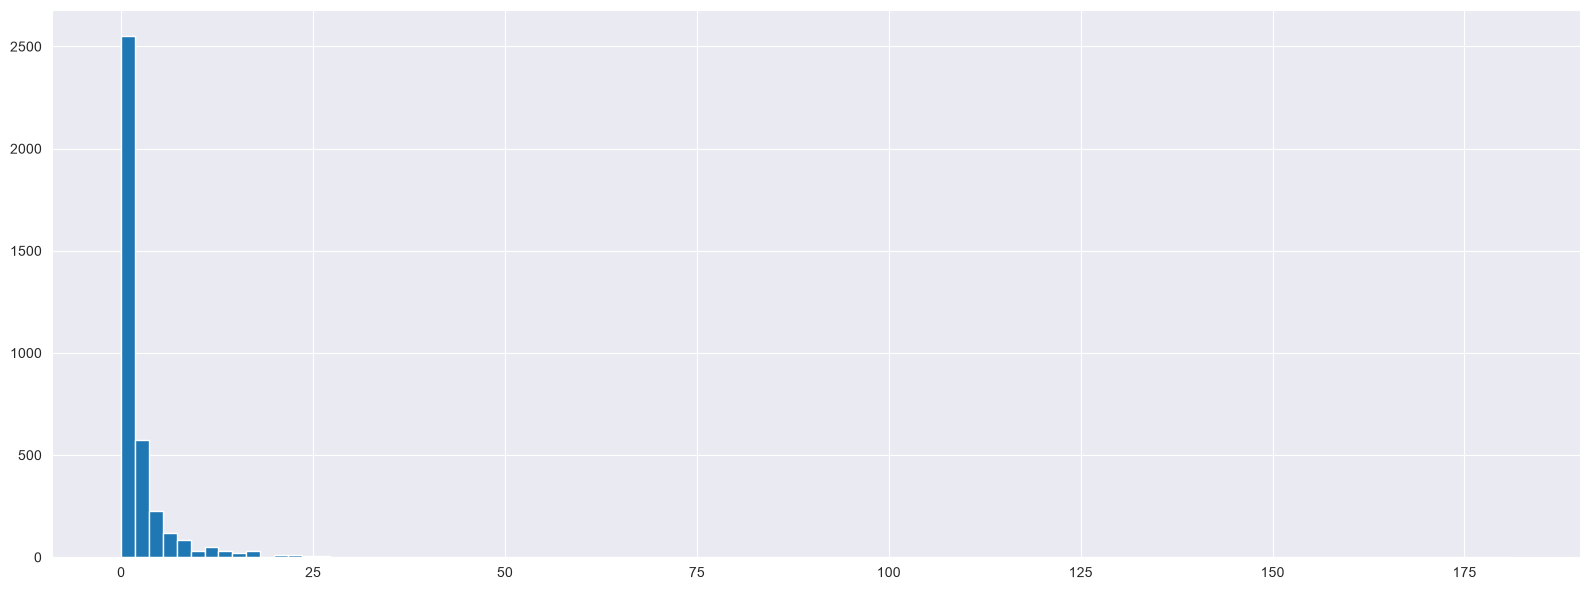

In [78]:
plt.figure(figsize=(16, 6))
plt.hist(products['Cancellations'], bins=100)

plt.tight_layout()

Distribution of cancellations per product is heavily right-skewed, meaning that most products have very few cancellations.

In [79]:
print('Percentage of Unique Products which Contribute in Cancellations:', percent(cancellation_rows['StockCode'].nunique(), purchase_rows['StockCode'].nunique()))

Percentage of Unique Products which Contribute in Cancellations: 51.26%


Only half of unique products are present in cancellations.

In [80]:
avg_high_value_products_cancellation_rate = high_value_products['CancellationRate'].mean()
avg_low_value_products_cancellation_rate = low_value_products['CancellationRate'].mean()
print('Average Cancellation Rate for High-Value Products:', avg_high_value_products_cancellation_rate)
print('Average Cancellation Rate for Low-Value Products:', avg_low_value_products_cancellation_rate)

Average Cancellation Rate for High-Value Products: 0.021213346847509057
Average Cancellation Rate for Low-Value Products: 0.01666974364815336


In [81]:
avg_high_value_products_cancellation_rate = high_value_products['CancellationRate'].mean()
avg_low_value_products_cancellation_rate = low_value_products['CancellationRate'].mean()
print('Average Cancellation Rate for High-Value Products:', avg_high_value_products_cancellation_rate)
print('Average Cancellation Rate for Low-Value Products:', avg_low_value_products_cancellation_rate)

Average Cancellation Rate for High-Value Products: 0.021213346847509057
Average Cancellation Rate for Low-Value Products: 0.01666974364815336


There doesn't seem to be much of a difference between average cancellation rates for high-value products and low-value products.

#### Customers & Cancellations

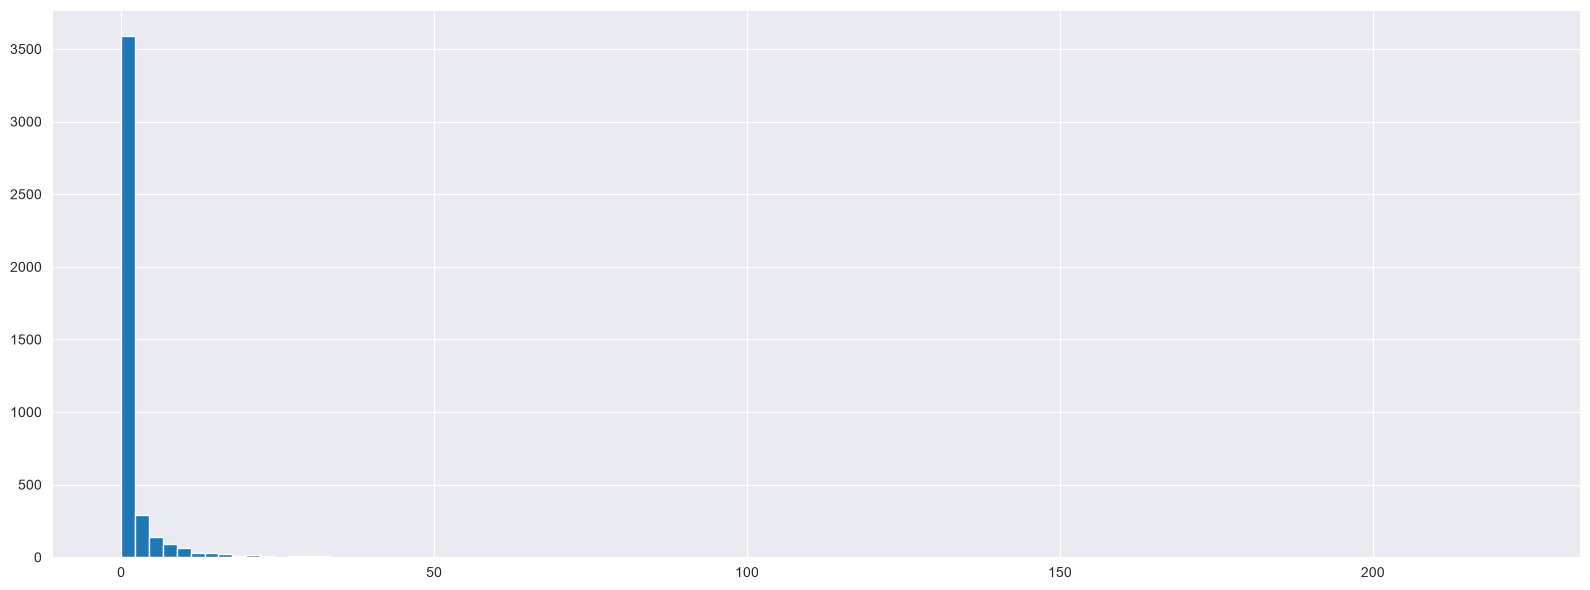

In [82]:
plt.figure(figsize=(16, 6))
plt.hist(customers['Cancellations'], bins=100)

plt.tight_layout()

Distribution of cancellations per customer is even more right-skewed than products', most customers have very few cancellations.

In [86]:
print('Percentage of Unique Customers which Contribute to Cancellations:', percent(cancelled_orders['CustomerID'].nunique(), orders['CustomerID'].nunique()))

Percentage of Unique Customers which Contribute to Cancellations: 35.39%


In [83]:
avg_high_value_customers_cancellation_rate = high_value_customers['CancellationRate'].mean()
avg_low_value_customers_cancellation_rate = low_value_customers['CancellationRate'].mean()
print('Average Cancellation Rate for High-Value Customers:', avg_high_value_customers_cancellation_rate)
print('Average Cancellation Rate for Low-Value Customers:', avg_low_value_customers_cancellation_rate)

Average Cancellation Rate for High-Value Customers: 0.029498738421050736
Average Cancellation Rate for Low-Value Customers: 0.02135450346613533


There doesn't seem to be much of a difference in customers either.

##### Missing Customers

In [84]:
missing_customers_cancellations_count = len(cancellation_rows[cancellation_rows['CustomerID'].isna()])
missing_customers_cancellations_value = np.abs(cancellation_rows[cancellation_rows['CustomerID'].isna()]['LineValue'].sum())
print('Cancellation with Missing Customers:', percent(missing_customers_cancellations_count, len(cancellation_rows)))
print('Value of Cancellations Associated with Missing Customers:', percent(missing_customers_cancellations_value, np.abs(cancellation_rows['LineValue'].sum())))

Cancellation with Missing Customers: 1.9%
Value of Cancellations Associated with Missing Customers: 0.9%


1.9% of cancellations aren't done by identified customers which contribute to 0.9% of total cancellation value.